# 딥러닝 실습 - MLP로 품질 예측

## 학습 목표

1. **Keras** 프레임워크의 기본 사용법을 익힘
2. **MLP(Multi-Layer Perceptron) 모델**을 구현하고 학습시킴
3. 학습 결과를 **분석하고 개선**함
4. **수학적 원리**를 이해하고 실무에 적용함

## 실습 데이터셋: Wine Quality (UCI Machine Learning Repository)

본 실습에서는 **포르투갈 Vinho Verde 와인**의 품질 예측 데이터셋을 활용함. 이 데이터셋은 와인 제조 공정에서 측정된 물리화학적 특성을 기반으로 와인의 품질 등급을 예측하는 실제 제조 품질 관리 문제임.

| 항목 | 내용 |
|:-----|:-----|
| 출처 | UCI Machine Learning Repository |
| 샘플 수 | 6,497건 (레드 1,599 + 화이트 4,898) |
| 입력 특성 | 11개 물리화학적 변수 |
| 출력 | 품질 등급 (0-10점) |
| 특징 | 클래스 불균형, 다중 분류/회귀 모두 가능 |

와인 품질 예측은 전형적인 **제조 품질 관리(Quality Control)** 문제임:

- **공정 변수 -> 품질 예측**: 제조 공정의 센서 데이터로 최종 제품 품질 예측
- **클래스 불균형**: 실제 제조 현장에서 불량품은 소수 (극단적 품질 등급이 적음)
- **다변량 입력**: 여러 공정 변수가 복합적으로 품질에 영향
- **비선형 관계**: 단순 선형 모델로는 포착하기 어려운 복잡한 패턴 존재

# 1. Keras 기초

## 1.1 Keras란 무엇인가?

**Keras**는 TensorFlow 위에서 동작하는 고수준(High-level) 딥러닝 API임. 복잡한 수학적 구현 없이도 직관적인 인터페이스로 신경망 모델을 구현할 수 있음.

### Keras의 설계 철학

1. **사용자 친화성(User-friendliness)**: 일관되고 간단한 API
2. **모듈성(Modularity)**: 층(Layer), 옵티마이저, 손실함수 등을 블록처럼 조립
3. **확장성(Extensibility)**: 커스텀 구성요소 쉽게 추가 가능
4. **Python 네이티브**: Python 코드와 자연스럽게 통합

### 저수준 vs 고수준 API 비교

| 구분 | 저수준 (NumPy 직접 구현) | 고수준 (Keras) |
|:-----|:------------------------|:--------------|
| 순전파 | 행렬 연산 직접 작성 | `model.predict()` |
| 역전파 | 미분 수식 직접 계산 | **자동 미분** |
| 경사하강법 | 업데이트 규칙 직접 구현 | 옵티마이저 선택만 |
| 코드량 | 수십~수백 줄 | **10줄 이내** |
| 디버깅 | 어려움 | 상대적으로 용이 |

In [2]:
# 필요 라이브러리 설치 및 임포트
#!pip install tensorflow pandas numpy matplotlib seaborn scikit-learn ucimlrepo --quiet

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import font_manager, rc
import warnings
warnings.filterwarnings('ignore')

# 한글 폰트 설정 (시스템에 따라 조정 필요)
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False

# 시각화 스타일
plt.style.use('seaborn-v0_8-whitegrid')

# TensorFlow/Keras 임포트
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'  # TensorFlow 경고 숨기기

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2

# sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (classification_report, confusion_matrix, 
                             roc_auc_score, roc_curve, accuracy_score)

print(f"TensorFlow Version: {tf.__version__}")
print(f"Keras Version: {keras.__version__}")
print(f"NumPy Version: {np.__version__}")
print(f"Pandas Version: {pd.__version__}")

TensorFlow Version: 2.20.0
Keras Version: 3.13.0
NumPy Version: 2.4.0
Pandas Version: 2.3.3


---

## 1.2 Keras 모델 개발 워크플로우

Keras를 사용한 딥러닝 모델 개발은 다음과 같은 체계적인 단계를 따름:

```mermaid
flowchart LR
    A["1. 데이터 준비<br/>(Data Preparation)"] --> B["2. 모델 설계\n(Model Design)"]
    B --> C["3. 컴파일<br/>(Compile)"]
    C --> D["4. 학습<br/>(Fit)"]
    D --> E["5. 평가<br/>(Evaluate)"]
    E --> F{성능<br/>만족?}
    F -->|No| G["하이퍼파라미터<br/>튜닝"]
    G --> B
    F -->|Yes| H["6. 저장 및 배포<br/>(Save & Deploy)"]
    
    style A fill:#e1f5fe
    style B fill:#fff3e0
    style C fill:#fff3e0
    style D fill:#fff3e0
    style E fill:#e8f5e9
    style F fill:#fce4ec
    style G fill:#f3e5f5
    style H fill:#c8e6c9
```

### 각 단계별 핵심 작업

| 단계 | 핵심 작업 | Keras 메서드/함수 |
|:-----|:---------|:------------------|
| 데이터 준비 | 로드, 정규화, 분할 | `sklearn` 활용 |
| 모델 설계 | 층 구조 정의 | `Sequential`, `Dense` |
| 컴파일 | 학습 설정 | `model.compile()` |
| 학습 | 가중치 최적화 | `model.fit()` |
| 평가 | 성능 측정 | `model.evaluate()` |
| 저장 | 모델 파일 저장 | `model.save()` |

## 1.3 Sequential 모델 이해

**Sequential** 모델은 층(Layer)을 순서대로 쌓아 구성하는 가장 기본적인 Keras 모델 유형임.

### Sequential 모델의 구조

```
Sequential 모델
    |
    +-- Input (입력 데이터)         <- 명시적 입력층 또는 input_shape로 지정
    |
    +-- Dense(64, activation='relu')    <- 은닉층 1: 64개 노드, ReLU 활성화
    |
    +-- Dense(32, activation='relu')    <- 은닉층 2: 32개 노드, ReLU 활성화
    |
    +-- Dense(1, activation='sigmoid')  <- 출력층: 1개 노드, Sigmoid (이진 분류)
    |
    v
    Output (예측값: 0~1 확률)
```

### Sequential 모델 생성 방법

Keras에서 Sequential 모델을 생성하는 두 가지 방법이 있음:

In [3]:
# 방법 1: 리스트로 층 전달
model_v1 = Sequential([
    Dense(64, activation='relu', input_shape=(11,)),  # 입력 11개 특성
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')  # 이진 분류
])

print("=== 방법 1: 리스트로 층 전달 ===")
model_v1.summary()

=== 방법 1: 리스트로 층 전달 ===


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 64)                  │             768 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,881 (11.25 KB)

 Trainable params: 2,881 (11.25 KB)

 Non-trainable params: 0 (0.00 B)

In [4]:
# 방법 2: add() 메서드로 층 추가
model_v2 = Sequential()
model_v2.add(Dense(64, activation='relu', input_shape=(11,)))
model_v2.add(Dense(32, activation='relu'))
model_v2.add(Dense(1, activation='sigmoid'))

print("=== 방법 2: add() 메서드 사용 ===")
model_v2.summary()

=== 방법 2: add() 메서드 사용 ===


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                      │ (None, 64)                  │             768 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,881 (11.25 KB)

 Trainable params: 2,881 (11.25 KB)

 Non-trainable params: 0 (0.00 B)

## 1.4 Dense(완전연결) 층의 이해

**Dense 층**은 이전 층의 모든 노드가 다음 층의 모든 노드와 연결되는 **완전연결층(Fully Connected Layer)**임.

### Dense 층의 수학적 표현

Dense 층의 출력은 다음과 같이 계산됨:

$$\mathbf{y} = f(\mathbf{W}\mathbf{x} + \mathbf{b})$$

여기서:
- $\mathbf{x} \in \mathbb{R}^{n_{in}}$: 입력 벡터 (이전 층의 출력)
- $\mathbf{W} \in \mathbb{R}^{n_{out} \times n_{in}}$: 가중치 행렬
- $\mathbf{b} \in \mathbb{R}^{n_{out}}$: 편향 벡터
- $f(\cdot)$: 활성화 함수 (ReLU, Sigmoid 등)
- $\mathbf{y} \in \mathbb{R}^{n_{out}}$: 출력 벡터

### 단일 뉴런의 계산 과정

하나의 뉴런 $j$에 대한 출력:

$$y_j = f\left(\sum_{i=1}^{n_{in}} w_{ji} x_i + b_j\right) = f(z_j)$$

여기서 $z_j = \sum_{i=1}^{n_{in}} w_{ji} x_i + b_j$는 **선형 결합(Linear Combination)** 또는 **가중합(Weighted Sum)**이라 함.

### Dense 층의 파라미터(가중치) 수 계산

$$\text{Parameters} = (n_{in} \times n_{out}) + n_{out}$$

- $n_{in} \times n_{out}$: 가중치 개수
- $n_{out}$: 편향 개수

### 계산 예시

입력 11개 -> Dense(64) -> Dense(32) -> Dense(1) 구조의 파라미터 수:

| 층 | 계산식 | 파라미터 수 |
|:--|:------|----------:|
| Input(11) -> Dense(64) | $(11 \times 64) + 64$ | 768 |
| Dense(64) -> Dense(32) | $(64 \times 32) + 32$ | 2,080 |
| Dense(32) -> Dense(1) | $(32 \times 1) + 1$ | 33 |
| **합계** | | **2,881** |

In [5]:
# 파라미터 수 직접 확인
print("=== 파라미터 수 확인 ===")
print(f"Layer 1: Input(11) -> Dense(64)")
print(f"  - 가중치: 11 x 64 = {11 * 64}")
print(f"  - 편향: 64")
print(f"  - 합계: {11 * 64 + 64}\n")

print(f"Layer 2: Dense(64) -> Dense(32)")
print(f"  - 가중치: 64 x 32 = {64 * 32}")
print(f"  - 편향: 32")
print(f"  - 합계: {64 * 32 + 32}\n")

print(f"Layer 3: Dense(32) -> Dense(1)")
print(f"  - 가중치: 32 x 1 = {32 * 1}")
print(f"  - 편향: 1")
print(f"  - 합계: {32 * 1 + 1}\n")

total_params = (11 * 64 + 64) + (64 * 32 + 32) + (32 * 1 + 1)
print(f"=== 총 파라미터 수: {total_params:,} ===")

=== 파라미터 수 확인 ===
Layer 1: Input(11) -> Dense(64)
  - 가중치: 11 x 64 = 704
  - 편향: 64
  - 합계: 768

Layer 2: Dense(64) -> Dense(32)
  - 가중치: 64 x 32 = 2048
  - 편향: 32
  - 합계: 2080

Layer 3: Dense(32) -> Dense(1)
  - 가중치: 32 x 1 = 32
  - 편향: 1
  - 합계: 33

=== 총 파라미터 수: 2,881 ===


## (복습) 1.5 활성화 함수(Activation Function)

활성화 함수는 신경망에 **비선형성(Non-linearity)**을 부여하여 복잡한 패턴을 학습할 수 있게 함.

### 활성화 함수가 필요한 이유

활성화 함수가 없으면 여러 층을 쌓아도 결국 **하나의 선형 변환**으로 축소됨:

$$\mathbf{y} = \mathbf{W}_2(\mathbf{W}_1\mathbf{x} + \mathbf{b}_1) + \mathbf{b}_2 = (\mathbf{W}_2\mathbf{W}_1)\mathbf{x} + (\mathbf{W}_2\mathbf{b}_1 + \mathbf{b}_2) = \mathbf{W}'\mathbf{x} + \mathbf{b}'$$

이는 단일 층과 동일한 표현력을 가짐. 비선형 활성화 함수를 추가해야 **깊은 네트워크의 이점**을 살릴 수 있음.

### 주요 활성화 함수

#### 1. ReLU (Rectified Linear Unit)

$$\text{ReLU}(z) = \max(0, z) = \begin{cases} z & \text{if } z > 0 \\ 0 & \text{if } z \leq 0 \end{cases}$$

- **용도**: 은닉층의 기본 활성화 함수
- **장점**: 계산이 빠르고, 기울기 소실 문제 완화
- **단점**: 음수 입력에서 기울기가 0 (Dead ReLU 문제)

#### 2. Sigmoid

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

- **용도**: 이진 분류의 출력층
- **출력 범위**: $(0, 1)$ - 확률로 해석 가능
- **단점**: 기울기 소실, 출력이 0 중심이 아님

#### 3. Softmax

$$\text{softmax}(z_i) = \frac{e^{z_i}}{\sum_{j=1}^{K} e^{z_j}}$$

- **용도**: 다중 클래스 분류의 출력층
- **특징**: 모든 출력의 합이 1 (확률 분포)

### 위치별 활성화 함수 선택 가이드

| 위치 | 문제 유형 | 권장 활성화 함수 |
|:-----|:---------|:----------------|
| 은닉층 | 모든 문제 | `'relu'` |
| 출력층 | 이진 분류 | `'sigmoid'` |
| 출력층 | 다중 분류 | `'softmax'` |
| 출력층 | 회귀 | `None` (linear) |

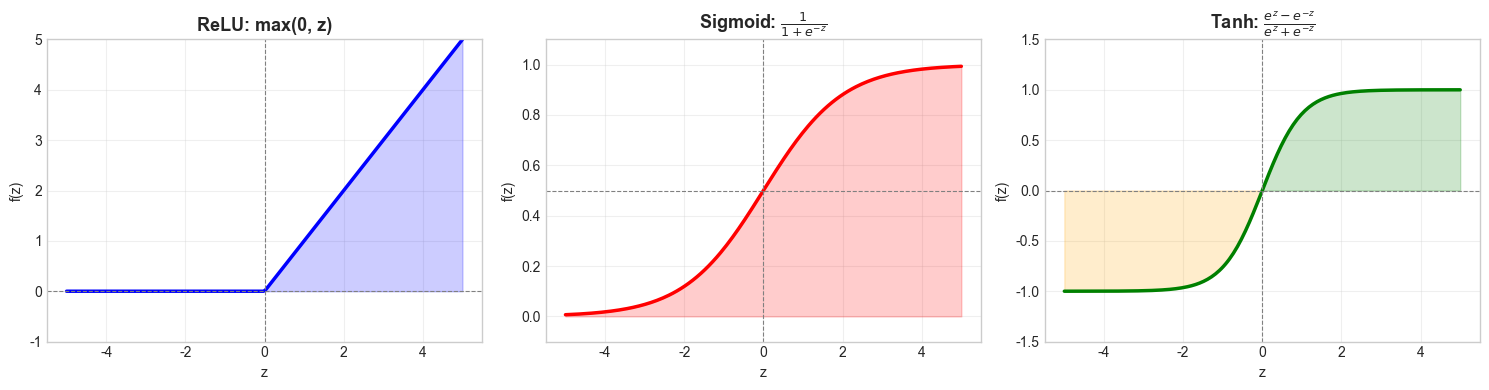

In [7]:
# 활성화 함수 시각화
z = np.linspace(-5, 5, 200)

# ReLU
relu = np.maximum(0, z)

# Sigmoid
sigmoid = 1 / (1 + np.exp(-z))

# Tanh (참고용)
tanh = np.tanh(z)

# 시각화
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# ReLU
axes[0].plot(z, relu, 'b-', linewidth=2.5)
axes[0].axhline(y=0, color='gray', linestyle='--', linewidth=0.8)
axes[0].axvline(x=0, color='gray', linestyle='--', linewidth=0.8)
axes[0].set_title('ReLU: max(0, z)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('z')
axes[0].set_ylabel('f(z)')
axes[0].set_ylim(-1, 5)
axes[0].grid(True, alpha=0.3)
axes[0].fill_between(z[z >= 0], 0, relu[z >= 0], alpha=0.2, color='blue')

# Sigmoid
axes[1].plot(z, sigmoid, 'r-', linewidth=2.5)
axes[1].axhline(y=0.5, color='gray', linestyle='--', linewidth=0.8)
axes[1].axvline(x=0, color='gray', linestyle='--', linewidth=0.8)
axes[1].set_title(r'Sigmoid: $\frac{1}{1+e^{-z}}$', fontsize=13, fontweight='bold')
axes[1].set_xlabel('z')
axes[1].set_ylabel('f(z)')
axes[1].set_ylim(-0.1, 1.1)
axes[1].grid(True, alpha=0.3)
axes[1].fill_between(z, 0, sigmoid, alpha=0.2, color='red')

# Tanh
axes[2].plot(z, tanh, 'g-', linewidth=2.5)
axes[2].axhline(y=0, color='gray', linestyle='--', linewidth=0.8)
axes[2].axvline(x=0, color='gray', linestyle='--', linewidth=0.8)
axes[2].set_title(r'Tanh: $\frac{e^z - e^{-z}}{e^z + e^{-z}}$', fontsize=13, fontweight='bold')
axes[2].set_xlabel('z')
axes[2].set_ylabel('f(z)')
axes[2].set_ylim(-1.5, 1.5)
axes[2].grid(True, alpha=0.3)
axes[2].fill_between(z, 0, tanh, where=(tanh > 0), alpha=0.2, color='green')
axes[2].fill_between(z, 0, tanh, where=(tanh < 0), alpha=0.2, color='orange')

plt.tight_layout()
plt.savefig('activation_functions.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

## 1.6 모델 컴파일(Compile)

모델 컴파일은 학습 과정에 필요한 **옵티마이저**, **손실 함수**, **평가 지표**를 설정하는 단계임.

```python
model.compile(
    optimizer='adam',           # 최적화 알고리즘
    loss='binary_crossentropy', # 손실 함수
    metrics=['accuracy']        # 평가 지표
)
```

### 1.6.1 옵티마이저(Optimizer)

옵티마이저는 손실 함수를 최소화하기 위해 **가중치를 업데이트하는 알고리즘**임.

#### 기본 경사하강법(Gradient Descent)

$$\mathbf{w}_{t+1} = \mathbf{w}_t - \eta \nabla L(\mathbf{w}_t)$$

- $\eta$: 학습률(Learning Rate)
- $\nabla L$: 손실 함수의 기울기

#### Adam 옵티마이저 (권장)

Adam(Adaptive Moment Estimation)은 **모멘텀**과 **RMSprop**을 결합한 적응적 학습률 알고리즘임.

**1차 모멘트 (평균, 관성):**
$$m_t = \beta_1 m_{t-1} + (1 - \beta_1) g_t$$

**2차 모멘트 (분산, 스케일 조정):**
$$v_t = \beta_2 v_{t-1} + (1 - \beta_2) g_t^2$$

**편향 보정:**
$$\hat{m}_t = \frac{m_t}{1 - \beta_1^t}, \quad \hat{v}_t = \frac{v_t}{1 - \beta_2^t}$$

**파라미터 업데이트:**
$$\mathbf{w}_{t+1} = \mathbf{w}_t - \frac{\eta}{\sqrt{\hat{v}_t} + \epsilon} \hat{m}_t$$

여기서:
- $g_t = \nabla L(\mathbf{w}_t)$: 현재 기울기
- $\beta_1 = 0.9$: 1차 모멘트 감쇠율 (기본값)
- $\beta_2 = 0.999$: 2차 모멘트 감쇠율 (기본값)
- $\epsilon = 10^{-7}$: 수치 안정성을 위한 작은 값
- $\eta = 0.001$: 기본 학습률

| 옵티마이저 | 특징 | 권장 상황 |
|:----------|:-----|:---------|
| `'sgd'` | 기본 경사하강법 | 단순 문제, 교육용 |
| `'adam'` | **가장 많이 사용**, 적응적 학습률 | **대부분의 문제 (기본 선택)** |
| `'rmsprop'` | 적응적 학습률 | RNN, 시계열 데이터 |

### 1.6.2 손실 함수(Loss Function)

손실 함수는 모델의 예측과 실제 값 사이의 **오차를 측정**하는 함수임. 학습의 목표는 이 손실을 최소화하는 것임.

#### Binary Cross-Entropy (이진 분류)

$$L = -\frac{1}{N}\sum_{i=1}^{N}\left[y_i \log(\hat{y}_i) + (1 - y_i) \log(1 - \hat{y}_i)\right]$$

여기서:
- $N$: 샘플 수
- $y_i \in \{0, 1\}$: 실제 레이블
- $\hat{y}_i \in (0, 1)$: 예측 확률 (Sigmoid 출력)

**손실 함수의 동작 원리:**

| 실제 레이블 | 손실 공식 | 해석 |
|:-----------|:---------|:-----|
| $y = 1$ | $-\log(\hat{y})$ | $\hat{y}$가 1에 가까울수록 손실 감소 |
| $y = 0$ | $-\log(1-\hat{y})$ | $\hat{y}$가 0에 가까울수록 손실 감소 |

#### Categorical Cross-Entropy (다중 분류)

$$L = -\frac{1}{N}\sum_{i=1}^{N}\sum_{c=1}^{C} y_{ic} \log(\hat{y}_{ic})$$

여기서:
- $C$: 클래스 수
- $y_{ic}$: 샘플 $i$가 클래스 $c$에 속하면 1, 아니면 0 (One-hot 인코딩)

#### Mean Squared Error (회귀)

$$L = \frac{1}{N}\sum_{i=1}^{N}(y_i - \hat{y}_i)^2$$

### 문제 유형별 손실 함수 선택

| 문제 유형 | 손실 함수 | 출력층 활성화 |
|:---------|:---------|:-------------|
| 이진 분류 | `'binary_crossentropy'` | `'sigmoid'` |
| 다중 분류 (One-hot) | `'categorical_crossentropy'` | `'softmax'` |
| 다중 분류 (정수 레이블) | `'sparse_categorical_crossentropy'` | `'softmax'` |
| 회귀 | `'mse'` 또는 `'mae'` | `None` |

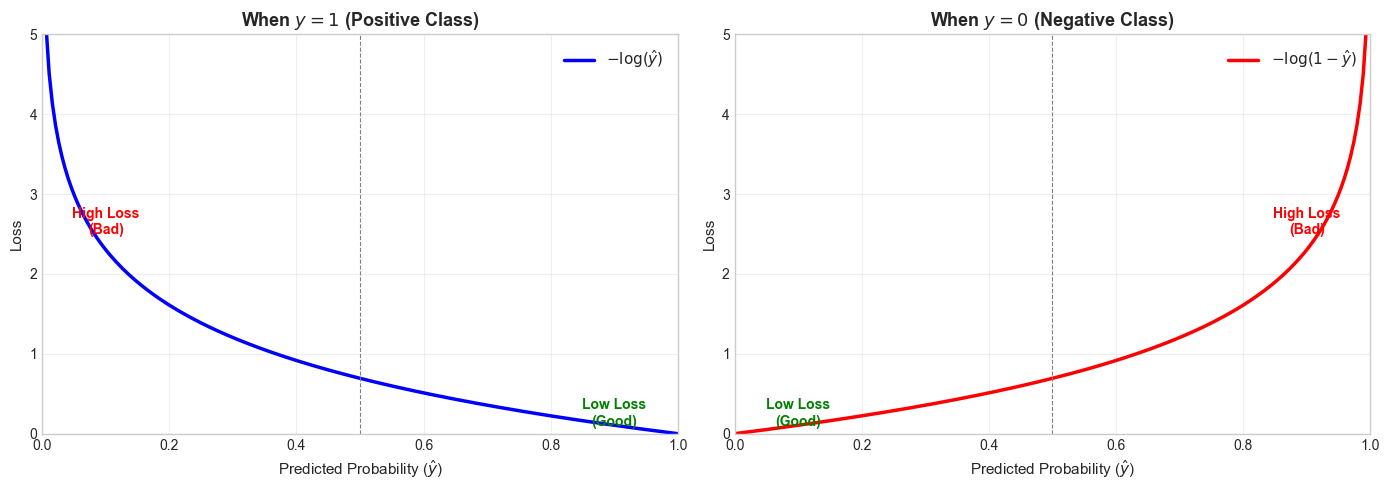

[Binary Cross-Entropy Interpretation]
- y=1: Penalizes predictions close to 0 heavily
- y=0: Penalizes predictions close to 1 heavily
- Encourages confident and correct predictions


In [8]:
# Binary Cross-Entropy 손실 함수 시각화
y_pred = np.linspace(0.001, 0.999, 200)  # 예측 확률

# y=1일 때 손실: -log(y_pred)
loss_y1 = -np.log(y_pred)

# y=0일 때 손실: -log(1-y_pred)
loss_y0 = -np.log(1 - y_pred)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# y=1일 때
axes[0].plot(y_pred, loss_y1, 'b-', linewidth=2.5, label=r'$-\log(\hat{y})$')
axes[0].axvline(x=0.5, color='gray', linestyle='--', linewidth=0.8)
axes[0].set_xlabel(r'Predicted Probability ($\hat{y}$)', fontsize=11)
axes[0].set_ylabel('Loss', fontsize=11)
axes[0].set_title(r'When $y = 1$ (Positive Class)', fontsize=13, fontweight='bold')
axes[0].set_xlim(0, 1)
axes[0].set_ylim(0, 5)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)
# 화살표로 해석 추가
axes[0].annotate('Low Loss\n(Good)', xy=(0.9, 0.1), fontsize=10, color='green',
                ha='center', fontweight='bold')
axes[0].annotate('High Loss\n(Bad)', xy=(0.1, 2.5), fontsize=10, color='red',
                ha='center', fontweight='bold')

# y=0일 때
axes[1].plot(y_pred, loss_y0, 'r-', linewidth=2.5, label=r'$-\log(1-\hat{y})$')
axes[1].axvline(x=0.5, color='gray', linestyle='--', linewidth=0.8)
axes[1].set_xlabel(r'Predicted Probability ($\hat{y}$)', fontsize=11)
axes[1].set_ylabel('Loss', fontsize=11)
axes[1].set_title(r'When $y = 0$ (Negative Class)', fontsize=13, fontweight='bold')
axes[1].set_xlim(0, 1)
axes[1].set_ylim(0, 5)
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)
axes[1].annotate('Low Loss\n(Good)', xy=(0.1, 0.1), fontsize=10, color='green',
                ha='center', fontweight='bold')
axes[1].annotate('High Loss\n(Bad)', xy=(0.9, 2.5), fontsize=10, color='red',
                ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('binary_crossentropy_loss.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

print("[Binary Cross-Entropy Interpretation]")
print("- y=1: Penalizes predictions close to 0 heavily")
print("- y=0: Penalizes predictions close to 1 heavily")
print("- Encourages confident and correct predictions")

# Part 2: MLP 모델 구현

## 2.1 데이터 로드 및 탐색

UCI Machine Learning Repository의 **Wine Quality** 데이터셋을 로드하고 탐색함.

### 데이터셋 개요

| 특성 | 설명 | 단위 |
|:-----|:-----|:-----|
| fixed acidity | 고정 산도 (주석산) | g/dm$^3$ |
| volatile acidity | 휘발성 산도 (아세트산) | g/dm$^3$ |
| citric acid | 구연산 | g/dm$^3$ |
| residual sugar | 잔류 당분 | g/dm$^3$ |
| chlorides | 염화물 | g/dm$^3$ |
| free sulfur dioxide | 유리 이산화황 | mg/dm$^3$ |
| total sulfur dioxide | 총 이산화황 | mg/dm$^3$ |
| density | 밀도 | g/cm$^3$ |
| pH | 산도 지수 | - |
| sulphates | 황산염 | g/dm$^3$ |
| alcohol | 알코올 도수 | % vol |
| **quality** | **품질 등급 (타겟)** | **0-10** |

In [9]:
# Wine Quality 데이터셋 로드
# UCI Repository에서 직접 다운로드

# Red Wine
url_red = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
df_red = pd.read_csv(url_red, sep=';')
df_red['wine_type'] = 'red'

# White Wine
url_white = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-white.csv"
df_white = pd.read_csv(url_white, sep=';')
df_white['wine_type'] = 'white'

# 병합
df = pd.concat([df_red, df_white], axis=0, ignore_index=True)

print("=" * 60)
print("Wine Quality Dataset")
print("=" * 60)
print(f"Red Wine Samples: {len(df_red):,}")
print(f"White Wine Samples: {len(df_white):,}")
print(f"Total Samples: {len(df):,}")
print(f"Features: {df.shape[1] - 2} (excluding 'quality' and 'wine_type')")
print("=" * 60)

Wine Quality Dataset
Red Wine Samples: 1,599
White Wine Samples: 4,898
Total Samples: 6,497
Features: 11 (excluding 'quality' and 'wine_type')


In [10]:
# 데이터 구조 확인
print(df.info())
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6497 non-null   float64
 1   volatile acidity      6497 non-null   float64
 2   citric acid           6497 non-null   float64
 3   residual sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free sulfur dioxide   6497 non-null   float64
 6   total sulfur dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  wine_type             6497 non-null   object 
dtypes: float64(11), int64(1), object(1)
memory usage: 660.0+ KB
None


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,wine_type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,red
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red


In [11]:
# 기술 통계량
print("=== Descriptive Statistics ===")
df.describe().round(3)

=== Descriptive Statistics ===


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,6497.000,6497.000,6497.000,6497.000,6497.000,6497.000,6497.000,6497.000,6497.000,6497.000,6497.000,6497.000
mean,7.215,0.340,0.319,5.443,0.056,30.525,115.745,0.995,3.219,0.531,10.492,5.818
std,1.296,0.165,0.145,4.758,0.035,17.749,56.522,0.003,0.161,0.149,1.193,0.873
min,3.800,0.080,0.000,0.600,0.009,1.000,6.000,0.987,2.720,0.220,8.000,3.000
25%,6.400,0.230,0.250,1.800,0.038,17.000,77.000,0.992,3.110,0.430,9.500,5.000
50%,7.000,0.290,0.310,3.000,0.047,29.000,118.000,0.995,3.210,0.510,10.300,6.000
75%,7.700,0.400,0.390,8.100,0.065,41.000,156.000,0.997,3.320,0.600,11.300,6.000
max,15.900,1.580,1.660,65.800,0.611,289.000,440.000,1.039,4.010,2.000,14.900,9.000


In [12]:
# 결측치 확인
print("=== Missing Values ===")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_df)
print(f"\nTotal Missing Values: {missing.sum()}")

=== Missing Values ===
                      Missing Count  Missing %
fixed acidity                     0        0.0
volatile acidity                  0        0.0
citric acid                       0        0.0
residual sugar                    0        0.0
chlorides                         0        0.0
free sulfur dioxide               0        0.0
total sulfur dioxide              0        0.0
density                           0        0.0
pH                                0        0.0
sulphates                         0        0.0
alcohol                           0        0.0
quality                           0        0.0
wine_type                         0        0.0

Total Missing Values: 0


## 2.2 탐색적 데이터 분석 (EDA)

데이터의 분포와 특성을 시각적으로 탐색함.

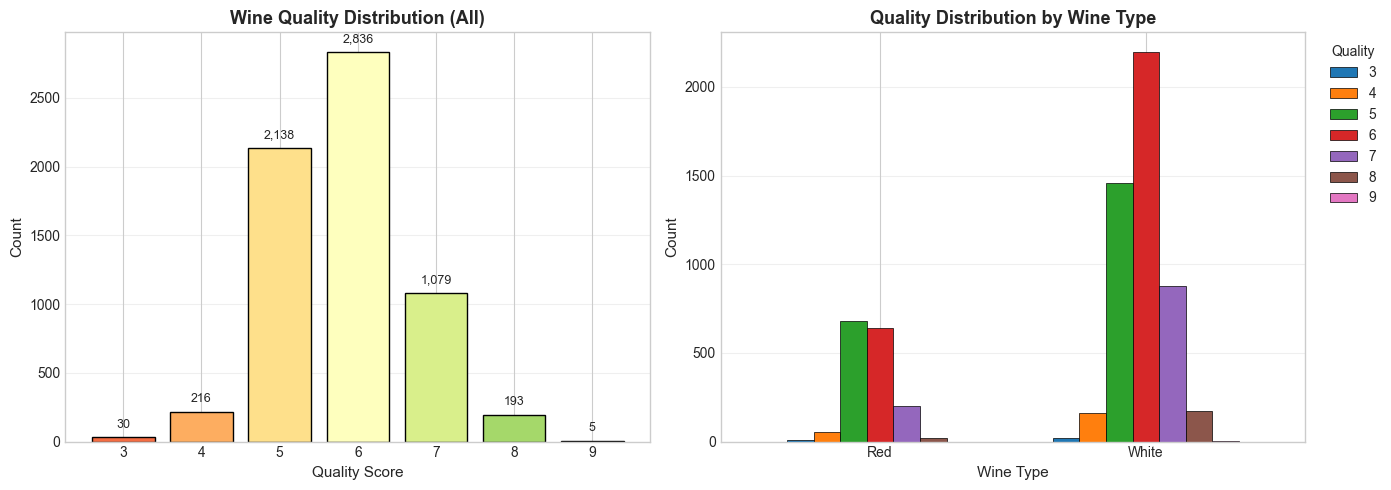

[Quality Distribution Analysis]
- Most wines have quality scores of 5 or 6 (typical quality)
- Very few wines have extreme scores (3, 4, 8, 9)
- Class Imbalance: Need to address for classification


In [13]:
# 품질 등급 분포
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 전체 품질 분포
quality_counts = df['quality'].value_counts().sort_index()
colors = plt.cm.RdYlGn(np.linspace(0.2, 0.8, len(quality_counts)))
bars = axes[0].bar(quality_counts.index.astype(str), quality_counts.values, 
                   color=colors, edgecolor='black', linewidth=1)
axes[0].set_xlabel('Quality Score', fontsize=11)
axes[0].set_ylabel('Count', fontsize=11)
axes[0].set_title('Wine Quality Distribution (All)', fontsize=13, fontweight='bold')
# 막대 위에 값 표시
for bar, count in zip(bars, quality_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                f'{count:,}', ha='center', va='bottom', fontsize=9)
axes[0].grid(axis='y', alpha=0.3)

# 와인 종류별 품질 분포
quality_by_type = df.groupby(['wine_type', 'quality']).size().unstack(fill_value=0)
quality_by_type.plot(kind='bar', ax=axes[1], width=0.7, edgecolor='black', linewidth=0.5)
axes[1].set_xlabel('Wine Type', fontsize=11)
axes[1].set_ylabel('Count', fontsize=11)
axes[1].set_title('Quality Distribution by Wine Type', fontsize=13, fontweight='bold')
axes[1].legend(title='Quality', bbox_to_anchor=(1.02, 1), loc='upper left')
axes[1].set_xticklabels(['Red', 'White'], rotation=0)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('quality_distribution.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

print("[Quality Distribution Analysis]")
print(f"- Most wines have quality scores of 5 or 6 (typical quality)")
print(f"- Very few wines have extreme scores (3, 4, 8, 9)")
print(f"- Class Imbalance: Need to address for classification")

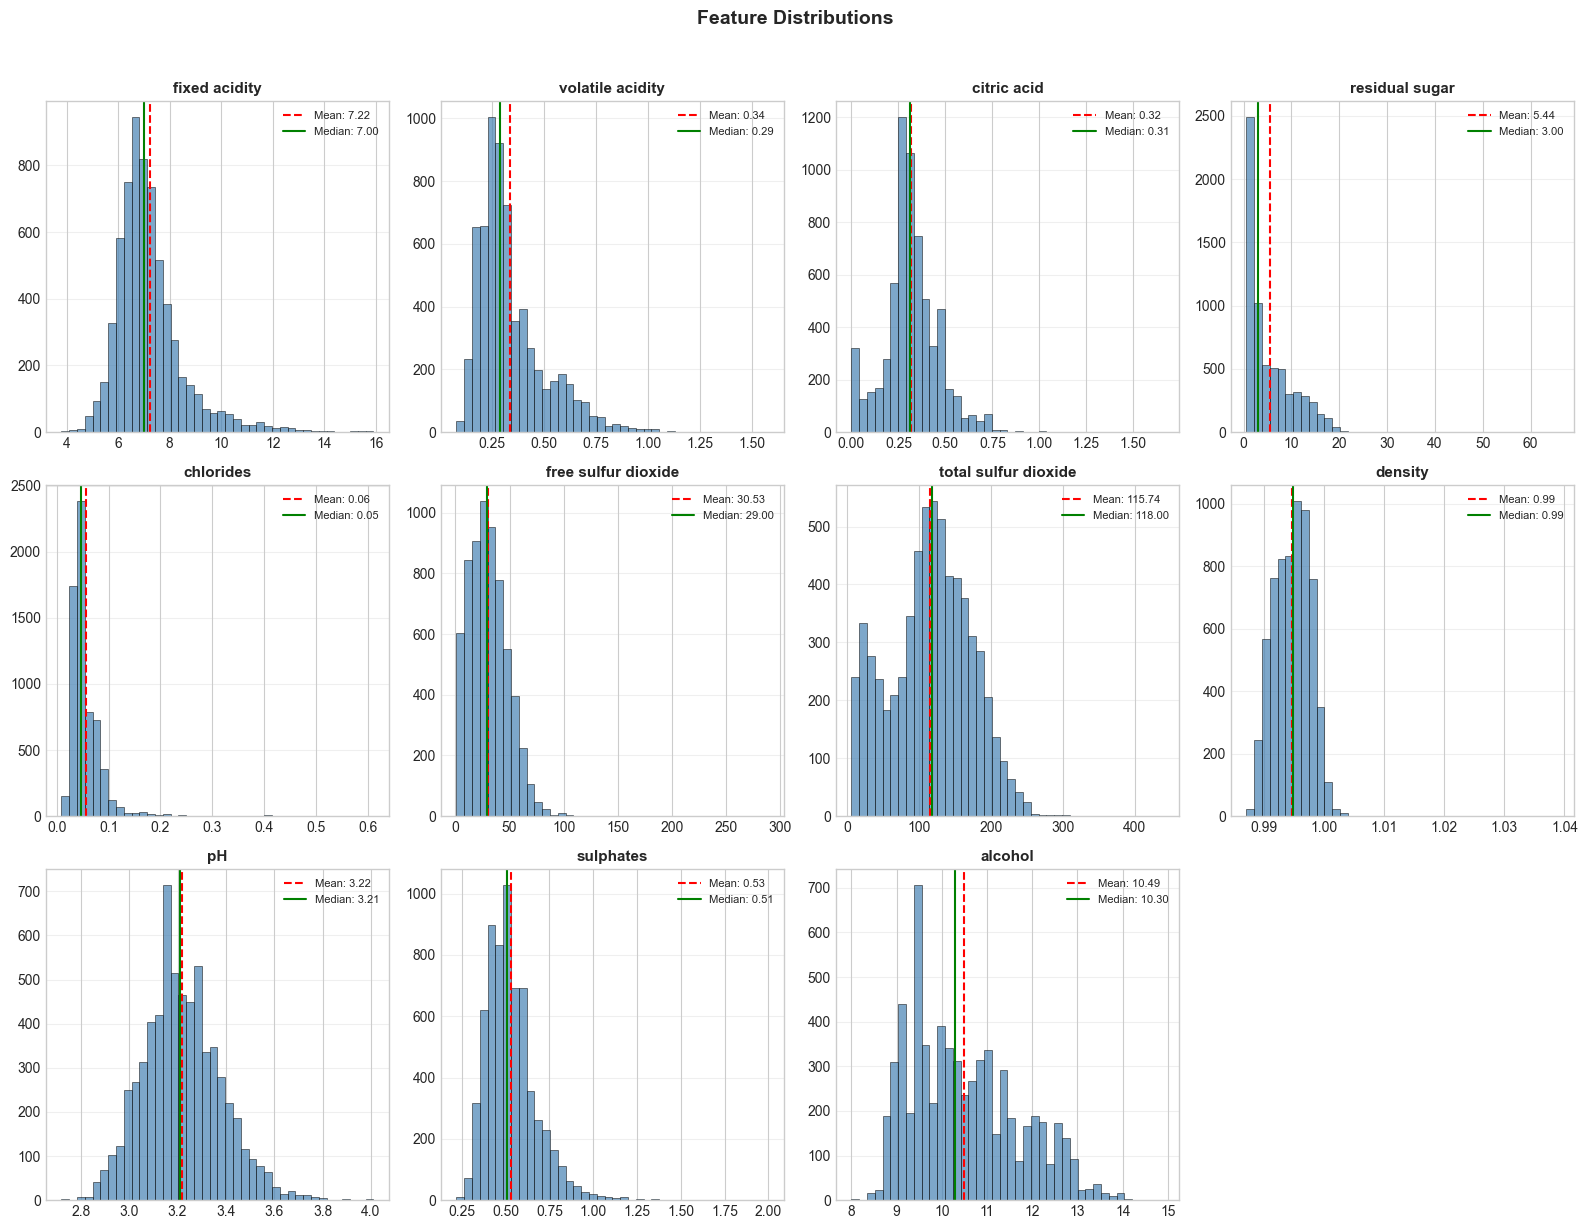

In [15]:
# 수치형 특성의 분포
numeric_cols = df.select_dtypes(include=[np.number]).columns.drop('quality')

fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    ax = axes[i]
    ax.hist(df[col], bins=40, color='steelblue', edgecolor='black', 
            alpha=0.7, linewidth=0.5)
    ax.axvline(df[col].mean(), color='red', linestyle='--', 
               linewidth=1.5, label=f'Mean: {df[col].mean():.2f}')
    ax.axvline(df[col].median(), color='green', linestyle='-', 
               linewidth=1.5, label=f'Median: {df[col].median():.2f}')
    ax.set_title(col, fontsize=11, fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3)

# 마지막 빈 플롯 숨기기
axes[-1].axis('off')

plt.suptitle('Feature Distributions', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

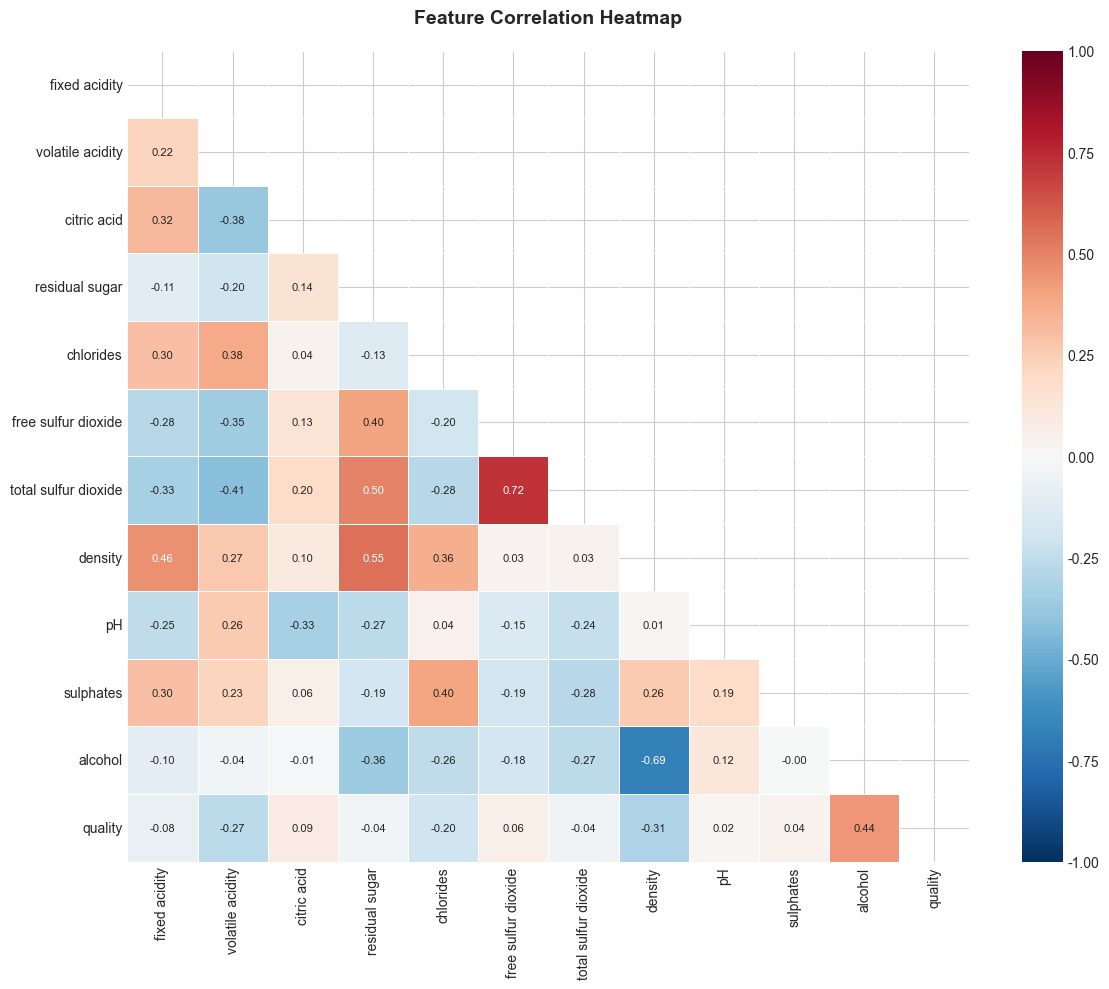

=== Correlation with Quality ===
alcohol                  : +0.444 (positive)
density                  : -0.306 (negative)
volatile acidity         : -0.266 (negative)
chlorides                : -0.201 (negative)
citric acid              : +0.086 (positive)
fixed acidity            : -0.077 (negative)
free sulfur dioxide      : +0.055 (positive)
total sulfur dioxide     : -0.041 (negative)
sulphates                : +0.038 (positive)
residual sugar           : -0.037 (negative)
pH                       : +0.020 (positive)


In [16]:
# 상관관계 히트맵
plt.figure(figsize=(12, 10))
correlation_matrix = df.drop(columns=['wine_type']).corr()

mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, mask=mask, annot=True, fmt='.2f', 
            cmap='RdBu_r', center=0, linewidths=0.5,
            annot_kws={'size': 8}, vmin=-1, vmax=1)
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

# 품질과의 상관관계
print("=== Correlation with Quality ===")
quality_corr = correlation_matrix['quality'].drop('quality').sort_values(key=abs, ascending=False)
for feature, corr in quality_corr.items():
    direction = "positive" if corr > 0 else "negative"
    print(f"{feature:25s}: {corr:+.3f} ({direction})")

## 2.3 데이터 전처리

### 2.3.1 문제 정의: 이진 분류로 변환

원래 품질 등급(3-9)을 **이진 분류** 문제로 변환함:

- **High Quality (1)**: 품질 등급 >= 7
- **Low Quality (0)**: 품질 등급 < 7

이러한 변환의 이유:
1. **MLP 기초 학습**에 적합한 단순한 문제로 변환
2. 실제 제조 현장에서의 **양품/불량품 판정**과 유사
3. 클래스 불균형 문제를 더 명확하게 관찰 가능

In [17]:
# 이진 분류 타겟 생성
df['quality_binary'] = (df['quality'] >= 7).astype(int)

print("=== Binary Classification Target ===")
print(f"High Quality (quality >= 7): {(df['quality_binary'] == 1).sum():,} samples")
print(f"Low Quality (quality < 7): {(df['quality_binary'] == 0).sum():,} samples")
print(f"\nClass Balance:")
print(f"  - High Quality: {df['quality_binary'].mean()*100:.1f}%")
print(f"  - Low Quality: {(1-df['quality_binary'].mean())*100:.1f}%")

=== Binary Classification Target ===
High Quality (quality >= 7): 1,277 samples
Low Quality (quality < 7): 5,220 samples

Class Balance:
  - High Quality: 19.7%
  - Low Quality: 80.3%


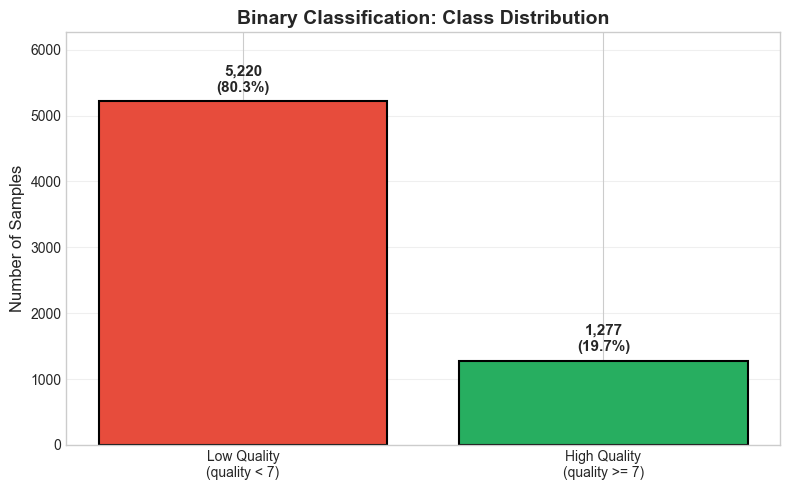

[Class Imbalance Issue]
- High Quality wines are minority class (~21.6%)
- Model may be biased towards predicting Low Quality
- Need to monitor Recall and F1-score, not just Accuracy


In [18]:
# 클래스 불균형 시각화
fig, ax = plt.subplots(figsize=(8, 5))

class_counts = df['quality_binary'].value_counts().sort_index()
colors = ['#e74c3c', '#27ae60']
labels = ['Low Quality\n(quality < 7)', 'High Quality\n(quality >= 7)']

bars = ax.bar(labels, class_counts.values, color=colors, edgecolor='black', linewidth=1.5)

for bar, count in zip(bars, class_counts.values):
    pct = count / len(df) * 100
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
           f'{count:,}\n({pct:.1f}%)', ha='center', va='bottom', 
           fontsize=11, fontweight='bold')

ax.set_ylabel('Number of Samples', fontsize=12)
ax.set_title('Binary Classification: Class Distribution', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, max(class_counts.values) * 1.2)

plt.tight_layout()
plt.savefig('class_imbalance.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

print("[Class Imbalance Issue]")
print("- High Quality wines are minority class (~21.6%)")
print("- Model may be biased towards predicting Low Quality")
print("- Need to monitor Recall and F1-score, not just Accuracy")

### 2.3.2 특성 스케일링 (정규화)

신경망 학습에서 데이터 정규화(Normalization/Standardization)는 필수적임.

#### 정규화가 필요한 이유

1. **스케일 차이 문제**: 특성별로 값의 범위가 크게 다르면 학습이 불안정해짐
2. **기울기 크기 불균형**: 큰 값을 가진 특성이 업데이트를 지배함
3. **활성화 함수 포화**: Sigmoid/Tanh의 포화 영역에 빠지기 쉬움

#### StandardScaler (Z-score 정규화)

$$z = \frac{x - \mu}{\sigma}$$

여기서:
- $x$: 원본 값
- $\mu$: 평균
- $\sigma$: 표준편차
- $z$: 정규화된 값 (평균 0, 표준편차 1)

#### 중요: 데이터 누출(Data Leakage) 방지

```mermaid
flowchart LR
    A[전체 데이터] --> B[Train/Test 분할]
    B --> C[Training Set]
    B --> D[Test Set]
    C --> E[Scaler fit_transform]
    E --> F[Scaled Train Data]
    D --> G[Scaler transform only]
    G --> H[Scaled Test Data]
    
    style E fill:#fff3e0
    style G fill:#e1f5fe
```

- **훈련 데이터**: `fit_transform()` - 평균/표준편차 계산 후 변환
- **테스트 데이터**: `transform()` - 훈련 데이터의 평균/표준편차로 변환 (재계산 금지)

In [19]:
# 특성과 타겟 분리
feature_cols = ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
                'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
                'pH', 'sulphates', 'alcohol']

X = df[feature_cols].values
y = df['quality_binary'].values

print(f"Feature Shape: {X.shape}")
print(f"Target Shape: {y.shape}")
print(f"\nFeature Ranges (Before Scaling):")
for i, col in enumerate(feature_cols):
    print(f"  {col:25s}: {X[:, i].min():.3f} ~ {X[:, i].max():.3f}")

Feature Shape: (6497, 11)
Target Shape: (6497,)

Feature Ranges (Before Scaling):
  fixed acidity            : 3.800 ~ 15.900
  volatile acidity         : 0.080 ~ 1.580
  citric acid              : 0.000 ~ 1.660
  residual sugar           : 0.600 ~ 65.800
  chlorides                : 0.009 ~ 0.611
  free sulfur dioxide      : 1.000 ~ 289.000
  total sulfur dioxide     : 6.000 ~ 440.000
  density                  : 0.987 ~ 1.039
  pH                       : 2.720 ~ 4.010
  sulphates                : 0.220 ~ 2.000
  alcohol                  : 8.000 ~ 14.900


In [20]:
# Train/Test 분할
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y  # 클래스 비율 유지
)

print("=== Train/Test Split ===")
print(f"Training Set: {len(X_train):,} samples ({len(X_train)/len(X)*100:.1f}%)")
print(f"Test Set: {len(X_test):,} samples ({len(X_test)/len(X)*100:.1f}%)")
print(f"\nClass Distribution (Training):")
print(f"  - High Quality: {y_train.sum():,} ({y_train.mean()*100:.1f}%)")
print(f"  - Low Quality: {(1-y_train).sum():,} ({(1-y_train.mean())*100:.1f}%)")

=== Train/Test Split ===
Training Set: 5,197 samples (80.0%)
Test Set: 1,300 samples (20.0%)

Class Distribution (Training):
  - High Quality: 1,021 (19.6%)
  - Low Quality: 4,176 (80.4%)


In [21]:
# 스케일링
scaler = StandardScaler()

# 훈련 데이터: fit_transform (평균/표준편차 계산 후 변환)
X_train_scaled = scaler.fit_transform(X_train)

# 테스트 데이터: transform only (훈련 데이터의 평균/표준편차 사용)
X_test_scaled = scaler.transform(X_test)

print("=== Scaling Applied ===")
print(f"\nTraining Data Statistics (After Scaling):")
print(f"  Mean: {X_train_scaled.mean(axis=0).mean():.6f} (should be ~0)")
print(f"  Std: {X_train_scaled.std(axis=0).mean():.6f} (should be ~1)")

print(f"\nFeature Ranges (After Scaling):")
for i, col in enumerate(feature_cols):
    print(f"  {col:25s}: {X_train_scaled[:, i].min():.3f} ~ {X_train_scaled[:, i].max():.3f}")

=== Scaling Applied ===

Training Data Statistics (After Scaling):
  Mean: 0.000000 (should be ~0)
  Std: 1.000000 (should be ~1)

Feature Ranges (After Scaling):
  fixed acidity            : -2.323 ~ 6.678
  volatile acidity         : -1.570 ~ 7.458
  citric acid              : -2.214 ~ 6.283
  residual sugar           : -0.992 ~ 12.725
  chlorides                : -1.311 ~ 15.374
  free sulfur dioxide      : -1.642 ~ 14.425
  total sulfur dioxide     : -1.933 ~ 5.740
  density                  : -2.509 ~ 14.647
  pH                       : -3.098 ~ 4.916
  sulphates                : -1.864 ~ 9.673
  alcohol                  : -2.096 ~ 3.689


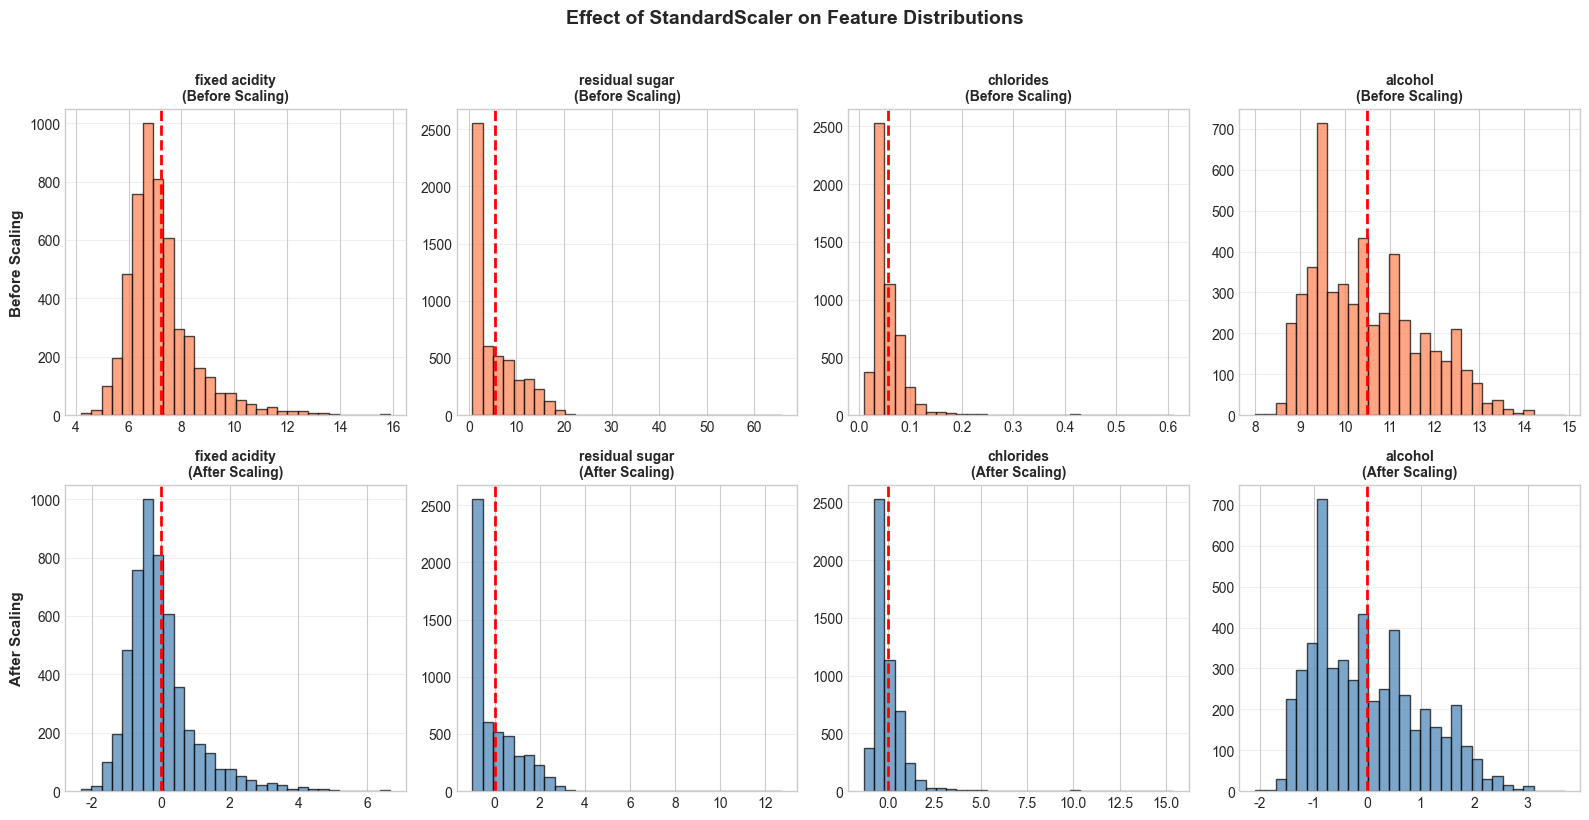

In [23]:
# 스케일링 효과 시각화
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

# 상위 4개 특성 선택
sample_features = [0, 3, 4, 10]  # fixed acidity, residual sugar, chlorides, alcohol

for i, feat_idx in enumerate(sample_features):
    col = feature_cols[feat_idx]
    
    # 스케일링 전
    axes[0, i].hist(X_train[:, feat_idx], bins=30, color='coral', 
                    edgecolor='black', alpha=0.7)
    axes[0, i].set_title(f'{col}\n(Before Scaling)', fontsize=10, fontweight='bold')
    axes[0, i].axvline(X_train[:, feat_idx].mean(), color='red', 
                       linestyle='--', linewidth=2)
    axes[0, i].grid(axis='y', alpha=0.3)
    
    # 스케일링 후
    axes[1, i].hist(X_train_scaled[:, feat_idx], bins=30, color='steelblue', 
                    edgecolor='black', alpha=0.7)
    axes[1, i].set_title(f'{col}\n(After Scaling)', fontsize=10, fontweight='bold')
    axes[1, i].axvline(0, color='red', linestyle='--', linewidth=2, label='Mean=0')
    axes[1, i].grid(axis='y', alpha=0.3)

axes[0, 0].set_ylabel('Before Scaling', fontsize=11, fontweight='bold')
axes[1, 0].set_ylabel('After Scaling', fontsize=11, fontweight='bold')

plt.suptitle('Effect of StandardScaler on Feature Distributions', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('scaling_effect.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

## 2.4 MLP 모델 설계

### 모델 아키텍처

와인 품질 이진 분류를 위한 MLP 구조:

```mermaid
flowchart TD
    subgraph Input["Input Layer"]
        I1["fixed_acidity"]
        I2["volatile_acidity"]
        I3["..."]
        I4["alcohol"]
    end
    
    subgraph H1["Hidden Layer 1: Dense(64, ReLU)"]
        H1_1(("ReLU"))
        H1_2(("ReLU"))
        H1_3(("..."))
    end
    
    subgraph H2["Hidden Layer 2: Dense(32, ReLU)"]
        H2_1(("ReLU"))
        H2_2(("..."))
    end
    
    subgraph H3["Hidden Layer 3: Dense(16, ReLU)"]
        H3_1(("ReLU"))
    end
    
    subgraph Output["Output Layer: Dense(1, Sigmoid)"]
        O1(("Sigmoid"))
    end
    
    I1 & I2 & I3 & I4 --> H1_1 & H1_2 & H1_3
    H1_1 & H1_2 & H1_3 --> H2_1 & H2_2
    H2_1 & H2_2 --> H3_1
    H3_1 --> O1
    O1 --> P["Prediction: 0.0 ~ 1.0"]
    P --> C{"Threshold\n> 0.5?"}
    C -->|Yes| HQ["High Quality"]
    C -->|No| LQ["Low Quality"]
    
    style Input fill:#e3f2fd
    style Output fill:#ffebee
```

In [24]:
# 기본 MLP 모델 (Dropout 없음) - 과적합 관찰용
model_basic = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
], name='basic_mlp')

model_basic.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("=== Basic MLP Model (No Regularization) ===")
model_basic.summary()

=== Basic MLP Model (No Regularization) ===


Model: "basic_mlp"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                      │ (None, 64)                  │             768 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,393 (13.25 KB)

 Trainable params: 3,393 (13.25 KB)

 Non-trainable params: 0 (0.00 B)

In [25]:
# 개선된 MLP 모델 (Dropout + BatchNormalization)
model_improved = Sequential([
    # Layer 1
    Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    BatchNormalization(),
    Dropout(0.3),
    
    # Layer 2
    Dense(32, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),
    
    # Layer 3
    Dense(16, activation='relu'),
    Dropout(0.1),
    
    # Output
    Dense(1, activation='sigmoid')
], name='improved_mlp')

model_improved.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("=== Improved MLP Model (With Regularization) ===")
model_improved.summary()

=== Improved MLP Model (With Regularization) ===


Model: "improved_mlp"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_10 (Dense)                     │ (None, 64)                  │             768 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 64)                  │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_11 (Dense)                     │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 32)                  │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_12 (Dense)                     │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 16)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_13 (Dense)                     │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,777 (14.75 KB)

 Trainable params: 3,585 (14.00 KB)

 Non-trainable params: 192 (768.00 B)

## 2.5 Dropout의 수학적 이해

**Dropout**은 학습 시 일부 노드를 무작위로 비활성화하여 **과적합(Overfitting)** 을 방지하는 정규화 기법임.

### Dropout의 동작 원리

$$\tilde{\mathbf{a}}^{(l)} = \mathbf{r}^{(l)} \odot \mathbf{a}^{(l)}, \quad \mathbf{r}^{(l)} \sim \text{Bernoulli}(p)$$

여기서:
- $\mathbf{a}^{(l)}$: $l$번째 층의 활성화 값
- $\mathbf{r}^{(l)}$: 베르누이 분포를 따르는 마스크 벡터 (0 또는 1)
- $p$: 노드 보존 확률 (예: `Dropout(0.3)`이면 $p = 0.7$)
- $\odot$: 원소별 곱셈 (Hadamard product)

### 학습 vs 추론 단계

| 단계 | 동작 |
|:-----|:-----|
| **학습(Training)** | 확률 $1-p$로 노드 비활성화 (출력을 0으로) |
| **추론(Inference)** | 모든 노드 활성화, 출력에 $p$ 곱하여 스케일 조정 |

```
학습 시 (Dropout rate = 0.3):
    [O] [X] [O] [O] [X] [O]  <- 30% 노드 무작위 비활성화
     1   0   1   1   0   1   <- Mask r

추론 시:
    [O] [O] [O] [O] [O] [O]  <- 모든 노드 활성화
     × 0.7 스케일링           <- 출력 보정
```

### Dropout의 효과

1. **앙상블 효과**: 매 학습 단계마다 다른 서브네트워크를 학습하는 것과 유사
2. **노드 의존성 감소**: 특정 노드에 과도하게 의존하는 것을 방지
3. **일반화 능력 향상**: 훈련 데이터에 대한 과적합 감소

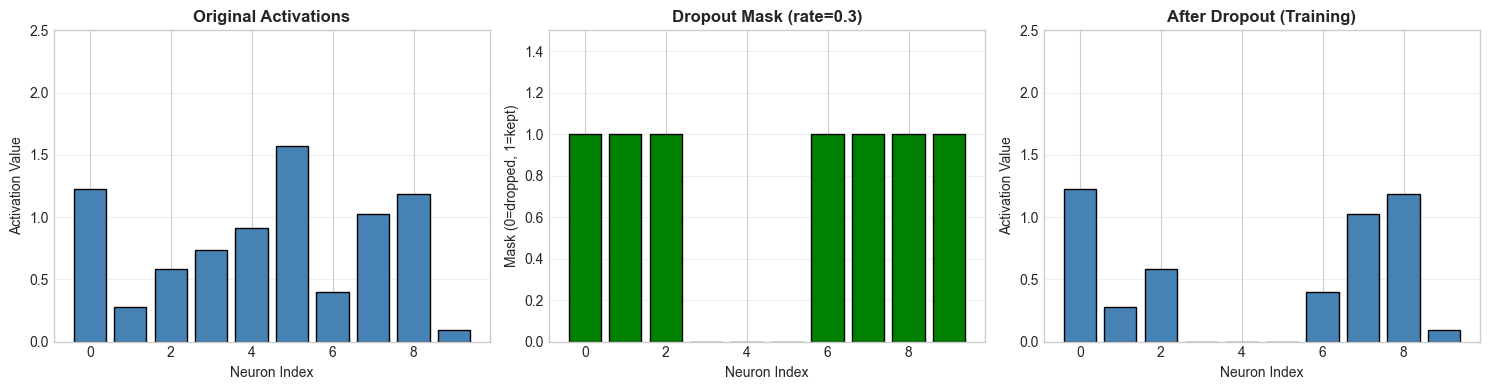

[Dropout Demonstration]
- Dropout rate: 0.3 (30% of neurons dropped)
- Original neurons: 10
- Dropped neurons: 3 (shown in red)
- Kept neurons: 7 (shown in blue/green)


In [27]:
# Dropout 동작 시각화
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 원본 활성화
n_neurons = 10
activations = np.random.rand(n_neurons) * 2

axes[0].bar(range(n_neurons), activations, color='steelblue', edgecolor='black')
axes[0].set_title('Original Activations', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Neuron Index')
axes[0].set_ylabel('Activation Value')
axes[0].set_ylim(0, 2.5)
axes[0].grid(axis='y', alpha=0.3)

# Dropout 마스크
dropout_rate = 0.3
mask = np.random.binomial(1, 1 - dropout_rate, n_neurons)
colors_mask = ['red' if m == 0 else 'green' for m in mask]

axes[1].bar(range(n_neurons), mask, color=colors_mask, edgecolor='black')
axes[1].set_title(f'Dropout Mask (rate={dropout_rate})', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Neuron Index')
axes[1].set_ylabel('Mask (0=dropped, 1=kept)')
axes[1].set_ylim(0, 1.5)
axes[1].grid(axis='y', alpha=0.3)

# Dropout 적용 후
activations_dropped = activations * mask
colors_dropped = ['red' if m == 0 else 'steelblue' for m in mask]

axes[2].bar(range(n_neurons), activations_dropped, color=colors_dropped, edgecolor='black')
axes[2].set_title('After Dropout (Training)', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Neuron Index')
axes[2].set_ylabel('Activation Value')
axes[2].set_ylim(0, 2.5)
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('dropout_visualization.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

print(f"[Dropout Demonstration]")
print(f"- Dropout rate: {dropout_rate} ({int(dropout_rate*100)}% of neurons dropped)")
print(f"- Original neurons: {n_neurons}")
print(f"- Dropped neurons: {(mask == 0).sum()} (shown in red)")
print(f"- Kept neurons: {mask.sum()} (shown in blue/green)")

## 2.6 모델 학습

### fit() 메서드 파라미터

| 파라미터 | 설명 | 권장값 |
|:---------|:-----|:-------|
| `epochs` | 전체 데이터 반복 횟수 | 50-200 |
| `batch_size` | 한 번에 학습할 샘플 수 | 32-128 |
| `validation_split` | 검증 데이터 비율 | 0.1-0.2 |
| `callbacks` | 학습 중 실행될 함수들 | EarlyStopping 등 |
| `verbose` | 출력 레벨 (0: 무출력, 1: 진행바, 2: 에포크별) | 1 |

### Batch Size와 학습의 관계

$$\text{Steps per Epoch} = \frac{\text{Training Samples}}{\text{Batch Size}}$$

예: 5,197개 훈련 샘플, batch_size=32:
$$\text{Steps} = \lceil 5197 / 32 \rceil = 163 \text{ steps/epoch}$$

In [28]:
# 기본 모델 학습 (과적합 관찰용)
print("=== Training Basic Model (No Regularization) ===")
print("Observe overfitting in this model...\n")

history_basic = model_basic.fit(
    X_train_scaled, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

print("\n=== Training Complete ===")

=== Training Basic Model (No Regularization) ===
Observe overfitting in this model...

Epoch 1/100
130/130 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7445 - loss: 0.5073 - val_accuracy: 0.8279 - val_loss: 0.3930
Epoch 2/100
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8244 - loss: 0.3902 - val_accuracy: 0.8279 - val_loss: 0.3680
Epoch 3/100
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8335 - loss: 0.3720 - val_accuracy: 0.8317 - val_loss: 0.3596
Epoch 4/100
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8335 - loss: 0.3586 - val_accuracy: 0.8260 - val_loss: 0.3508
Epoch 5/100
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8326 - loss: 0.3504 - val_accuracy: 0.8288 - val_loss: 0.3511
Epoch 6/100
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8386 - loss: 0.3415 - val_accuracy: 0.8346 - val_loss: 0.3459
Epoch 7/100
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8518 - loss: 0.3370 - val_accuracy: 0.8365 - val_loss: 0.3446
Epoch 8/10

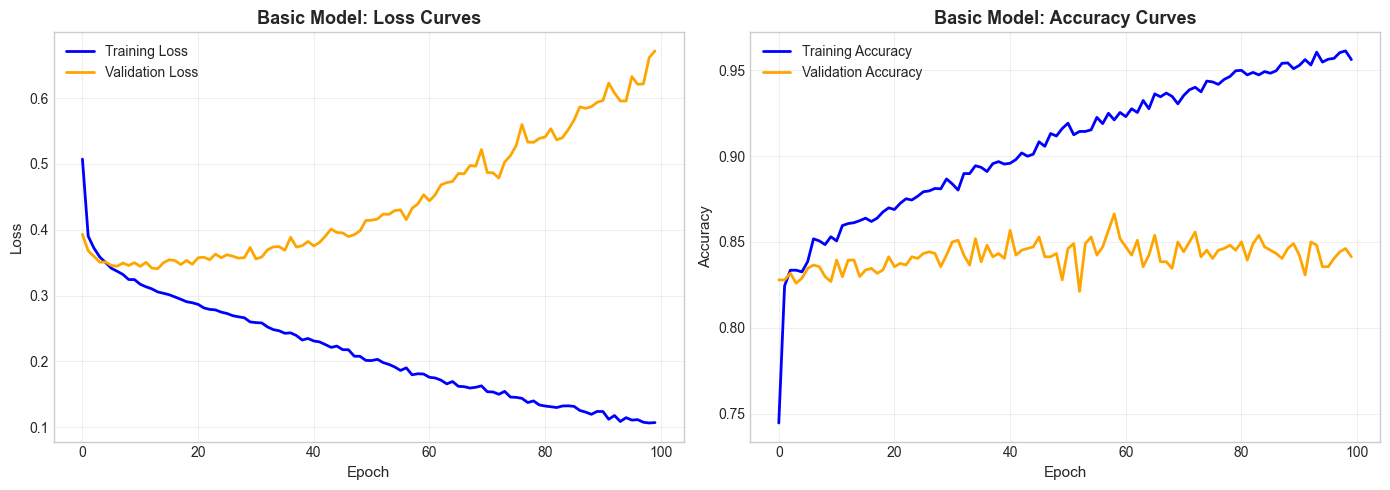

[Learning Curve Analysis - Basic Model]
- Training loss decreases continuously
- Validation loss may increase after certain epoch -> OVERFITTING
- Gap between train and validation -> Model memorizing training data


In [29]:
# 학습 곡선 시각화 (기본 모델)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(history_basic.history['loss'], label='Training Loss', linewidth=2, color='blue')
axes[0].plot(history_basic.history['val_loss'], label='Validation Loss', linewidth=2, color='orange')
axes[0].set_xlabel('Epoch', fontsize=11)
axes[0].set_ylabel('Loss', fontsize=11)
axes[0].set_title('Basic Model: Loss Curves', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(history_basic.history['accuracy'], label='Training Accuracy', linewidth=2, color='blue')
axes[1].plot(history_basic.history['val_accuracy'], label='Validation Accuracy', linewidth=2, color='orange')
axes[1].set_xlabel('Epoch', fontsize=11)
axes[1].set_ylabel('Accuracy', fontsize=11)
axes[1].set_title('Basic Model: Accuracy Curves', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('basic_model_learning_curves.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

print("[Learning Curve Analysis - Basic Model]")
print("- Training loss decreases continuously")
print("- Validation loss may increase after certain epoch -> OVERFITTING")
print("- Gap between train and validation -> Model memorizing training data")

In [30]:
# 개선된 모델 학습 (Dropout + Early Stopping)
print("=== Training Improved Model (With Regularization) ===")

# 콜백 설정
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=0.00001,
    verbose=1
)

history_improved = model_improved.fit(
    X_train_scaled, y_train,
    epochs=200,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

print("\n=== Training Complete ===")
print(f"Stopped at epoch: {len(history_improved.history['loss'])}")

=== Training Improved Model (With Regularization) ===
Epoch 1/200
130/130 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7051 - loss: 0.5645 - val_accuracy: 0.8163 - val_loss: 0.4353 - learning_rate: 0.0010
Epoch 2/200
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7975 - loss: 0.4390 - val_accuracy: 0.8192 - val_loss: 0.3863 - learning_rate: 0.0010
Epoch 3/200
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8088 - loss: 0.4137 - val_accuracy: 0.8231 - val_loss: 0.3692 - learning_rate: 0.0010
Epoch 4/200
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8145 - loss: 0.4071 - val_accuracy: 0.8183 - val_loss: 0.3658 - learning_rate: 0.0010
Epoch 5/200
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8097 - loss: 0.4005 - val_accuracy: 0.8298 - val_loss: 0.3581 - learning_rate: 0.0010
Epoch 6/200
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8138 - loss: 0.3915 - val_accuracy: 0.8279 - val_loss: 0.3553 - learning_rate: 0.0010
Epoch 7/200
130/130 ━━━━━━━━

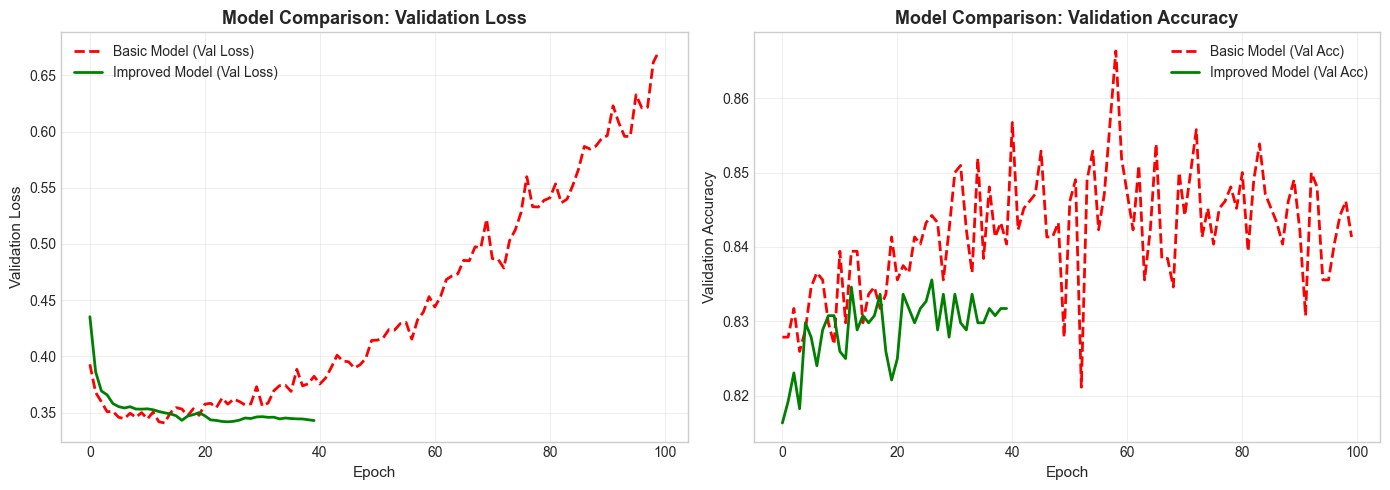

[Model Comparison]
- Improved model: More stable validation loss
- Early stopping prevents unnecessary training
- Dropout reduces overfitting


In [31]:
# 학습 곡선 비교 (기본 vs 개선)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss 비교
axes[0].plot(history_basic.history['val_loss'], label='Basic Model (Val Loss)', 
             linewidth=2, color='red', linestyle='--')
axes[0].plot(history_improved.history['val_loss'], label='Improved Model (Val Loss)', 
             linewidth=2, color='green')
axes[0].set_xlabel('Epoch', fontsize=11)
axes[0].set_ylabel('Validation Loss', fontsize=11)
axes[0].set_title('Model Comparison: Validation Loss', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Accuracy 비교
axes[1].plot(history_basic.history['val_accuracy'], label='Basic Model (Val Acc)', 
             linewidth=2, color='red', linestyle='--')
axes[1].plot(history_improved.history['val_accuracy'], label='Improved Model (Val Acc)', 
             linewidth=2, color='green')
axes[1].set_xlabel('Epoch', fontsize=11)
axes[1].set_ylabel('Validation Accuracy', fontsize=11)
axes[1].set_title('Model Comparison: Validation Accuracy', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('model_comparison_curves.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

print("[Model Comparison]")
print("- Improved model: More stable validation loss")
print("- Early stopping prevents unnecessary training")
print("- Dropout reduces overfitting")

## 2.7 모델 평가

### 분류 모델 평가 지표

#### Confusion Matrix (혼동 행렬)

|  | Predicted Positive | Predicted Negative |
|:---|:---:|:---:|
| **Actual Positive** | True Positive (TP) | False Negative (FN) |
| **Actual Negative** | False Positive (FP) | True Negative (TN) |

#### 주요 평가 지표

**Accuracy (정확도):**
$$\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}$$

**Precision (정밀도):**
$$\text{Precision} = \frac{TP}{TP + FP}$$
- "양성 예측" 중 실제 양성 비율
- "High Quality라고 예측한 것 중 실제 High Quality 비율"

**Recall (재현율, Sensitivity):**
$$\text{Recall} = \frac{TP}{TP + FN}$$
- "실제 양성" 중 양성 예측 비율
- "실제 High Quality 중 모델이 맞춘 비율"

**F1-Score:**
$$F_1 = 2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}$$
- Precision과 Recall의 조화 평균

**AUC-ROC:**
- ROC 곡선 아래 면적
- 0.5: 랜덤 추측, 1.0: 완벽한 분류

In [32]:
# 테스트 데이터로 평가
print("=== Model Evaluation on Test Set ===")

# 기본 모델
loss_basic, acc_basic = model_basic.evaluate(X_test_scaled, y_test, verbose=0)
print(f"\nBasic Model:")
print(f"  Test Loss: {loss_basic:.4f}")
print(f"  Test Accuracy: {acc_basic:.4f} ({acc_basic*100:.2f}%)")

# 개선된 모델
loss_improved, acc_improved = model_improved.evaluate(X_test_scaled, y_test, verbose=0)
print(f"\nImproved Model:")
print(f"  Test Loss: {loss_improved:.4f}")
print(f"  Test Accuracy: {acc_improved:.4f} ({acc_improved*100:.2f}%)")

=== Model Evaluation on Test Set ===

Basic Model:
  Test Loss: 0.5838
  Test Accuracy: 0.8546 (85.46%)

Improved Model:
  Test Loss: 0.3702
  Test Accuracy: 0.8208 (82.08%)


In [33]:
# 예측 및 상세 평가
y_pred_prob = model_improved.predict(X_test_scaled, verbose=0)
y_pred = (y_pred_prob > 0.5).astype(int).ravel()

# AUC Score
auc_score = roc_auc_score(y_test, y_pred_prob)

print("=== Detailed Evaluation (Improved Model) ===")
print(f"\nAUC-ROC Score: {auc_score:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, 
                           target_names=['Low Quality (0)', 'High Quality (1)']))

=== Detailed Evaluation (Improved Model) ===

AUC-ROC Score: 0.8396

Classification Report:
                  precision    recall  f1-score   support

 Low Quality (0)       0.86      0.93      0.89      1044
High Quality (1)       0.57      0.38      0.45       256

        accuracy                           0.82      1300
       macro avg       0.71      0.65      0.67      1300
    weighted avg       0.80      0.82      0.81      1300



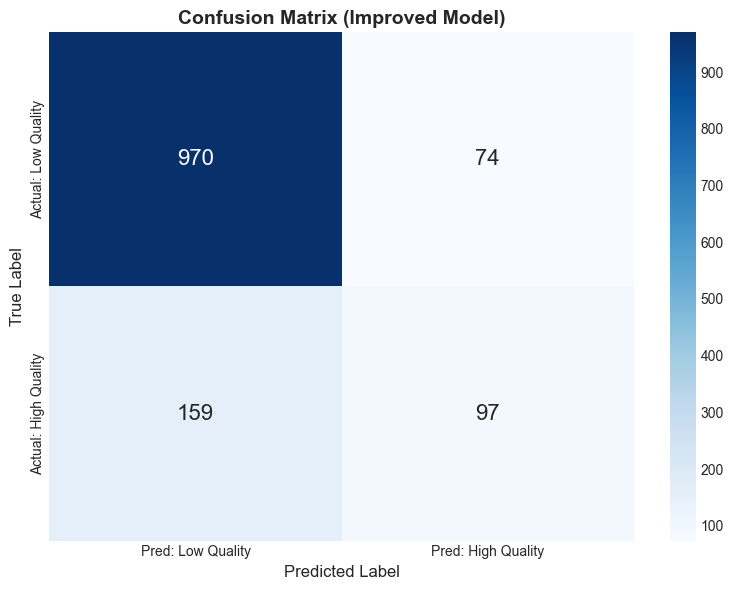

=== Confusion Matrix Interpretation ===
True Negative (TN): 970 - Correctly predicted as Low Quality
False Positive (FP): 74 - Low Quality predicted as High Quality
False Negative (FN): 159 - High Quality predicted as Low Quality
True Positive (TP): 97 - Correctly predicted as High Quality


In [34]:
# 혼동 행렬 시각화
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred: Low Quality', 'Pred: High Quality'],
            yticklabels=['Actual: Low Quality', 'Actual: High Quality'],
            annot_kws={'size': 16})
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)
ax.set_title('Confusion Matrix (Improved Model)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

# 혼동 행렬 해석
tn, fp, fn, tp = cm.ravel()
print("=== Confusion Matrix Interpretation ===")
print(f"True Negative (TN): {tn} - Correctly predicted as Low Quality")
print(f"False Positive (FP): {fp} - Low Quality predicted as High Quality")
print(f"False Negative (FN): {fn} - High Quality predicted as Low Quality")
print(f"True Positive (TP): {tp} - Correctly predicted as High Quality")

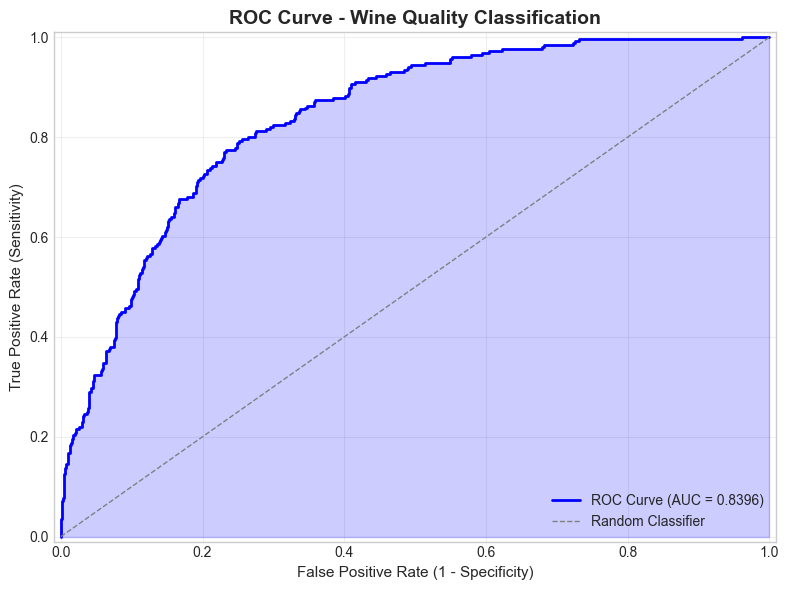

[ROC Curve Interpretation]
- AUC = 0.5: Random classifier (diagonal line)
- AUC = 1.0: Perfect classifier
- Current AUC = 0.8396: Good discrimination ability


In [35]:
# ROC 곡선
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr, tpr, color='blue', linewidth=2, label=f'ROC Curve (AUC = {auc_score:.4f})')
ax.plot([0, 1], [0, 1], color='gray', linestyle='--', linewidth=1, label='Random Classifier')
ax.fill_between(fpr, tpr, alpha=0.2, color='blue')

ax.set_xlabel('False Positive Rate (1 - Specificity)', fontsize=11)
ax.set_ylabel('True Positive Rate (Sensitivity)', fontsize=11)
ax.set_title('ROC Curve - Wine Quality Classification', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xlim([-0.01, 1.01])
ax.set_ylim([-0.01, 1.01])

plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

print("[ROC Curve Interpretation]")
print("- AUC = 0.5: Random classifier (diagonal line)")
print("- AUC = 1.0: Perfect classifier")
print(f"- Current AUC = {auc_score:.4f}: {'Good' if auc_score > 0.7 else 'Moderate'} discrimination ability")

# 3. MLP 모델의 개선?

## 3.1 과적합(Overfitting) 문제와 해결책

### 과적합의 징후

| 지표 | 정상 학습 | 과적합 |
|:-----|:---------|:-------|
| 훈련 손실 | 감소 | 계속 감소 |
| 검증 손실 | 감소 | **증가** |
| 훈련 정확도 | 상승 | 계속 상승 |
| 검증 정확도 | 상승 | **정체/하락** |

### 과적합 해결 기법

```mermaid
flowchart TD
    A[과적합 발생] --> B{원인 분석}
    B --> C[모델이 복잡함]
    B --> D[데이터가 부족함]
    B --> E[학습 시간이 김]
    
    C --> F[Dropout 추가]
    C --> G[L2 정규화]
    C --> H[모델 구조 단순화]
    
    D --> I[데이터 증강]
    D --> J[더 많은 데이터 수집]
    
    E --> K[Early Stopping]
    E --> L[학습률 조정]
    
    style A fill:#ffcdd2
    style F fill:#c8e6c9
    style G fill:#c8e6c9
    style K fill:#c8e6c9
```

### 3.1.1 L2 정규화 (Weight Decay)

L2 정규화는 손실 함수에 가중치의 제곱합 항을 추가하여 가중치가 커지는 것을 방지함.

$$L_{total} = L_{data} + \lambda \sum_{i} w_i^2$$

여기서:
- $L_{data}$: 원래 손실 함수 (Binary Cross-Entropy 등)
- $\lambda$: 정규화 강도 (하이퍼파라미터)
- $\sum w_i^2$: 모든 가중치의 제곱합

**효과**: 가중치 값을 작게 유지하여 모델의 복잡도를 제한함

In [36]:
# L2 정규화 적용 모델
from tensorflow.keras.regularizers import l2

model_l2 = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],),
          kernel_regularizer=l2(0.01)),
    Dropout(0.3),
    Dense(32, activation='relu', kernel_regularizer=l2(0.01)),
    Dropout(0.2),
    Dense(16, activation='relu', kernel_regularizer=l2(0.01)),
    Dense(1, activation='sigmoid')
], name='l2_regularized_mlp')

model_l2.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("=== L2 Regularized Model ===")
model_l2.summary()

=== L2 Regularized Model ===


Model: "l2_regularized_mlp"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_14 (Dense)                     │ (None, 64)                  │             768 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_15 (Dense)                     │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_16 (Dense)                     │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_17 (Dense)                     │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,393 (13.25 KB)

 Trainable params: 3,393 (13.25 KB)

 Non-trainable params: 0 (0.00 B)

In [37]:
# L2 모델 학습
history_l2 = model_l2.fit(
    X_train_scaled, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

# 평가
loss_l2, acc_l2 = model_l2.evaluate(X_test_scaled, y_test, verbose=0)
print(f"\nL2 Regularized Model:")
print(f"  Test Accuracy: {acc_l2:.4f} ({acc_l2*100:.2f}%)")

Epoch 1/100
130/130 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7652 - loss: 1.0975 - val_accuracy: 0.8096 - val_loss: 0.8015
Epoch 2/100
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8025 - loss: 0.6999 - val_accuracy: 0.8106 - val_loss: 0.5830
Epoch 3/100
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8064 - loss: 0.5523 - val_accuracy: 0.8163 - val_loss: 0.4923
Epoch 4/100
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8104 - loss: 0.4881 - val_accuracy: 0.8260 - val_loss: 0.4538
Epoch 5/100
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8150 - loss: 0.4625 - val_accuracy: 0.8260 - val_loss: 0.4361
Epoch 6/100
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8177 - loss: 0.4463 - val_accuracy: 0.8269 - val_loss: 0.4264
Epoch 7/100
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8177 - loss: 0.4383 - val_accuracy: 0.8250 - val_loss: 0.4211
Epoch 8/100
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8179 - loss: 0.4338 - val_accu

### 3.1.2 콜백(Callbacks) 활용

콜백은 학습 과정 중 특정 시점에 실행되는 함수들임.

| 콜백 | 기능 | 주요 파라미터 |
|:-----|:-----|:-------------|
| `EarlyStopping` | 개선이 없으면 학습 조기 종료 | `patience`, `restore_best_weights` |
| `ModelCheckpoint` | 최적 모델 저장 | `save_best_only`, `monitor` |
| `ReduceLROnPlateau` | 정체 시 학습률 감소 | `factor`, `patience` |
| `TensorBoard` | 학습 과정 시각화 | `log_dir` |

In [38]:
# 콜백 상세 설정 예시
callbacks_detailed = [
    # EarlyStopping: 15 에포크 동안 검증 손실 개선 없으면 종료
    EarlyStopping(
        monitor='val_loss',
        patience=15,
        restore_best_weights=True,
        verbose=1
    ),
    
    # ModelCheckpoint: 최적 모델 저장
    ModelCheckpoint(
        'best_wine_model.keras',
        monitor='val_loss',
        save_best_only=True,
        verbose=0
    ),
    
    # ReduceLROnPlateau: 5 에포크 정체 시 학습률 50% 감소
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=0.00001,
        verbose=1
    )
]

print("[Callbacks Configuration]")
print("- EarlyStopping: Stop if val_loss doesn't improve for 15 epochs")
print("- ModelCheckpoint: Save best model to 'best_wine_model.keras'")
print("- ReduceLROnPlateau: Reduce LR by 0.5x if val_loss stagnates for 5 epochs")

[Callbacks Configuration]
- EarlyStopping: Stop if val_loss doesn't improve for 15 epochs
- ModelCheckpoint: Save best model to 'best_wine_model.keras'
- ReduceLROnPlateau: Reduce LR by 0.5x if val_loss stagnates for 5 epochs


## 3.2 ML vs DL 성능 비교

동일한 데이터셋에서 전통적인 ML 모델과 MLP의 성능을 비교함.

In [39]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

# ML 모델들 학습 및 평가
print("=== ML vs DL Performance Comparison ===")

results = {}

# Logistic Regression
lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train_scaled, y_train)
results['Logistic Regression'] = lr.score(X_test_scaled, y_test)

# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_scaled, y_train)
results['Random Forest'] = rf.score(X_test_scaled, y_test)

# Gradient Boosting
gb = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb.fit(X_train_scaled, y_train)
results['Gradient Boosting'] = gb.score(X_test_scaled, y_test)

# SVM
svm = SVC(random_state=42)
svm.fit(X_train_scaled, y_train)
results['SVM'] = svm.score(X_test_scaled, y_test)

# MLP (Improved)
results['MLP (Keras)'] = acc_improved

# 결과 출력
print("\nTest Accuracy Results:")
for model_name, accuracy in sorted(results.items(), key=lambda x: x[1], reverse=True):
    print(f"  {model_name:25s}: {accuracy:.4f} ({accuracy*100:.2f}%)")

=== ML vs DL Performance Comparison ===

Test Accuracy Results:
  Random Forest            : 0.8823 (88.23%)
  Gradient Boosting        : 0.8415 (84.15%)
  SVM                      : 0.8308 (83.08%)
  Logistic Regression      : 0.8215 (82.15%)
  MLP (Keras)              : 0.8208 (82.08%)


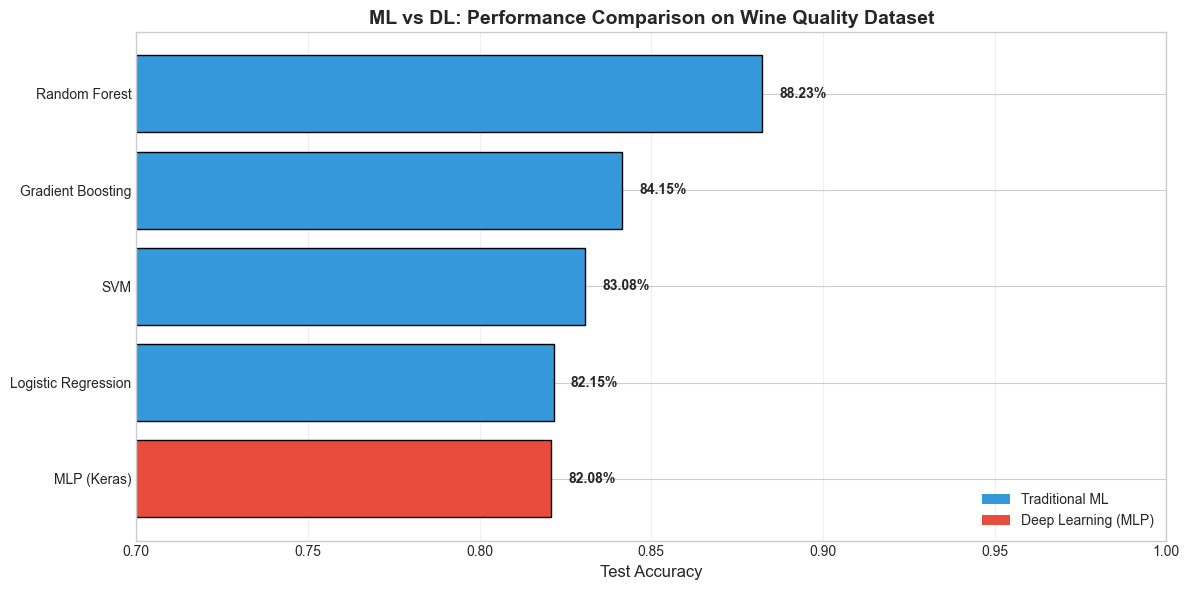

In [40]:
# 모델 비교 시각화
fig, ax = plt.subplots(figsize=(12, 6))

models = list(results.keys())
accuracies = list(results.values())

# 색상 (MLP만 다른 색)
colors = ['#3498db' if 'MLP' not in m else '#e74c3c' for m in models]

# 정렬
sorted_idx = np.argsort(accuracies)
models_sorted = [models[i] for i in sorted_idx]
acc_sorted = [accuracies[i] for i in sorted_idx]
colors_sorted = [colors[i] for i in sorted_idx]

bars = ax.barh(models_sorted, acc_sorted, color=colors_sorted, edgecolor='black', linewidth=1)

# 값 표시
for bar, acc in zip(bars, acc_sorted):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
           f'{acc:.2%}', va='center', fontsize=10, fontweight='bold')

ax.set_xlabel('Test Accuracy', fontsize=12)
ax.set_title('ML vs DL: Performance Comparison on Wine Quality Dataset', 
             fontsize=14, fontweight='bold')
ax.set_xlim(0.7, 1.0)
ax.grid(axis='x', alpha=0.3)

# 범례
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#3498db', label='Traditional ML'),
                   Patch(facecolor='#e74c3c', label='Deep Learning (MLP)')]
ax.legend(handles=legend_elements, loc='lower right', fontsize=10)

plt.tight_layout()
plt.show()

## 3.3 모델 저장 및 로드

In [ ]:
# 모델 저장
model_improved.save('wine_quality_mlp.keras')
print("Model saved to 'wine_quality_mlp.keras'")

# 모델 로드
from tensorflow.keras.models import load_model
loaded_model = load_model('wine_quality_mlp.keras')
print("Model loaded successfully")

# 로드한 모델로 예측
sample_predictions = loaded_model.predict(X_test_scaled[:5], verbose=0)

print("\n=== Sample Predictions ===")
for i in range(5):
    pred_prob = sample_predictions[i, 0]
    pred_class = "High Quality" if pred_prob > 0.5 else "Low Quality"
    actual_class = "High Quality" if y_test[i] == 1 else "Low Quality"
    match = "[CORRECT]" if (pred_prob > 0.5) == y_test[i] else "[WRONG]"
    print(f"Sample {i+1}: Prob={pred_prob:.4f} -> {pred_class:12s} | Actual: {actual_class:12s} {match}")

# 핵심 정리

## 학습 내용 요약

### 1. Keras 기초
- **Sequential 모델**: 층을 순서대로 쌓는 기본 구조
- **Dense 층**: 완전연결층, 파라미터 수 = $(n_{in} \times n_{out}) + n_{out}$
- **활성화 함수**: 은닉층은 ReLU, 출력층은 문제 유형에 따라 선택
- **컴파일**: optimizer(Adam), loss(binary_crossentropy), metrics(accuracy)

### 2. MLP 구현
- **데이터 전처리**: StandardScaler로 정규화 필수 ($z = \frac{x-\mu}{\sigma}$)
- **모델 설계**: 층 구조 및 노드 수 결정
- **학습**: `model.fit()`으로 가중치 최적화
- **평가**: Accuracy, Precision, Recall, F1-Score, AUC-ROC

### 3. 개선 기법
- **Dropout**: 과적합 방지, 학습 시 노드 무작위 비활성화
- **L2 정규화**: 손실에 $\lambda \sum w_i^2$ 추가
- **Early Stopping**: 검증 손실 개선 없으면 조기 종료
- **Learning Rate Scheduling**: 학습 정체 시 학습률 감소

---

## 핵심 수식 요약

| 수식 | 의미 |
|:-----|:-----|
| $\mathbf{y} = f(\mathbf{W}\mathbf{x} + \mathbf{b})$ | Dense 층 계산 |
| $\text{Params} = (n_{in} \times n_{out}) + n_{out}$ | 층별 파라미터 수 |
| $L = -\frac{1}{N}\sum[y\log(\hat{y}) + (1-y)\log(1-\hat{y})]$ | Binary Cross-Entropy |
| $\tilde{\mathbf{a}} = \mathbf{r} \odot \mathbf{a}, \ \mathbf{r} \sim \text{Bernoulli}(p)$ | Dropout |
| $L_{total} = L_{data} + \lambda \sum w_i^2$ | L2 정규화 |
| $z = \frac{x - \mu}{\sigma}$ | StandardScaler (Z-score) |

---

## 핵심 코드 템플릿

```python
# 1. 데이터 준비
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 2. 모델 생성
model = Sequential([
    Dense(64, activation='relu', input_shape=(n_features,)),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

# 3. 컴파일
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 4. 학습
history = model.fit(
    X_train_scaled, y_train,
    epochs=100,
    validation_split=0.2,
    callbacks=[EarlyStopping(patience=15, restore_best_weights=True)]
)

# 5. 평가
model.evaluate(X_test_scaled, y_test)
```

---

## 체크리스트

- [ ] 데이터 로드 및 탐색적 분석 완료
- [ ] StandardScaler로 특성 정규화
- [ ] Sequential 모델 생성 (Dense, Dropout)
- [ ] compile() - optimizer, loss, metrics 설정
- [ ] fit() - epochs, batch_size, validation_split, callbacks
- [ ] 학습 곡선 시각화 및 해석
- [ ] evaluate()로 테스트 평가
- [ ] 혼동 행렬, ROC 곡선 분석
- [ ] 모델 저장 및 로드

---

# [참고자료] 하이퍼파라미터 튜닝

---

## A.1 하이퍼파라미터 개요

| 파라미터 | 탐색 범위 | 영향 |
|:---------|:---------|:-----|
| 은닉층 수 | 1-4개 | 모델 복잡도, 표현력 |
| 노드 수 | 16, 32, 64, 128, 256 | 층별 표현력 |
| Dropout rate | 0.1-0.5 | 정규화 강도 |
| 학습률 | 0.0001-0.01 | 수렴 속도, 안정성 |
| 배치 크기 | 16, 32, 64, 128 | 학습 안정성, 메모리 |
| L2 강도 | 0.001-0.1 | 가중치 제한 |

In [ ]:
# 간단한 하이퍼파라미터 탐색 예시
from itertools import product

# 탐색할 하이퍼파라미터
hidden_sizes = [[64, 32], [128, 64, 32], [64, 32, 16]]
dropout_rates = [0.2, 0.3]
learning_rates = [0.001, 0.0005]

print("=== Hyperparameter Search ===")
print(f"Total combinations: {len(hidden_sizes) * len(dropout_rates) * len(learning_rates)}\n")

best_acc = 0
best_config = None
search_results = []

for hidden, dropout, lr in product(hidden_sizes, dropout_rates, learning_rates):
    # 모델 생성
    model_search = Sequential()
    model_search.add(Dense(hidden[0], activation='relu', input_shape=(X_train_scaled.shape[1],)))
    model_search.add(Dropout(dropout))
    
    for h in hidden[1:]:
        model_search.add(Dense(h, activation='relu'))
        model_search.add(Dropout(dropout * 0.7))  # 점진적 감소
    
    model_search.add(Dense(1, activation='sigmoid'))
    
    model_search.compile(
        optimizer=Adam(learning_rate=lr),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    
    # 학습 (조용히)
    model_search.fit(
        X_train_scaled, y_train,
        epochs=50,
        batch_size=32,
        validation_split=0.2,
        callbacks=[EarlyStopping(patience=10, restore_best_weights=True, verbose=0)],
        verbose=0
    )
    
    # 평가
    _, acc = model_search.evaluate(X_test_scaled, y_test, verbose=0)
    
    config = {'hidden': hidden, 'dropout': dropout, 'lr': lr, 'accuracy': acc}
    search_results.append(config)
    
    if acc > best_acc:
        best_acc = acc
        best_config = config
    
    print(f"Hidden={hidden}, Dropout={dropout}, LR={lr} -> Acc={acc:.4f}")

print(f"\n=== Best Configuration ===")
print(f"Hidden Layers: {best_config['hidden']}")
print(f"Dropout Rate: {best_config['dropout']}")
print(f"Learning Rate: {best_config['lr']}")
print(f"Test Accuracy: {best_config['accuracy']:.4f} ({best_config['accuracy']*100:.2f}%)")

---

## A.2 학습률과 배치 크기의 관계

**Linear Scaling Rule**: 배치 크기를 $k$배 늘리면 학습률도 $k$배 늘리는 것이 일반적임.

| 배치 크기 | 특징 | 권장 학습률 |
|:---------|:-----|:-----------|
| 16 | 노이즈 높음, 일반화 좋을 수 있음 | 0.0005-0.001 |
| 32 | 균형 잡힘 (기본 선택) | 0.001 |
| 64 | 안정적, 빠름 | 0.001-0.002 |
| 128+ | 매우 안정적, GPU 효율적 | 0.002-0.01 |

---

## A.3 언제 딥러닝을 사용해야 하는가?

| 상황 | 권장 접근법 | 이유 |
|:-----|:-----------|:-----|
| 정형 데이터 (테이블) + 소량 | Traditional ML (GB, RF) | 해석 가능, 빠른 학습 |
| 정형 데이터 + 대용량 | MLP 또는 TabNet | DL이 복잡한 패턴 포착 가능 |
| 이미지 데이터 | CNN | 공간적 특성 추출에 최적 |
| 시계열/순차 데이터 | RNN, LSTM, Transformer | 시간적 의존성 학습 |
| 자연어 처리 | Transformer (BERT 등) | 문맥 이해에 강점 |
| 특성 엔지니어링 어려움 | Deep Learning | 자동 특성 학습 |